# Case study: sc-SVC analysis of CAF states and stromal niches in Xenium data

## Notebook Guide

**Purpose.** Preserve and explain the sc-SVC analysis workflow for the Xenium fibroblast dataset.

**Inputs.** Use either the real-world ST raw data required for reconstruction or the released fibroblast `spatial.h5ad` / `expr.h5ad` pair described below; raw Xenium/reference objects are additional downstream analysis inputs.

### Two ways to obtain the analysis inputs

1. **Reconstruct locally.** Download the [Real-world ST datasets](https://zenodo.org/records/21921802), place `P2CRC_Xenium.h5ad` and `adata_sc_all_reanno.h5ad` under `../../raw_data/Real_application/`, and run `python reconstruct.py --config configs/application/Xenium.yaml --select-ct Fibroblast` from the repository root.
2. **Start from released results.** Download the [REVISE-reconstructed sc-SVC Xenium data](https://zenodo.org/records/18389211) and place the fibroblast pair at `../../results/sc_SVC_case/P2CRC_Xenium/Fibroblast/spatial.h5ad` and `../../results/sc_SVC_case/P2CRC_Xenium/Fibroblast/expr.h5ad`. Then begin with **Load the reconstructed CAF objects** below.

**Reconstruction input.** The route starts from `../../raw_data/Real_application/P2CRC_Xenium.h5ad` and `../../raw_data/Real_application/adata_sc_all_reanno.h5ad`. The spatial object provides counts and `obsm["spatial"]`; the reference provides shared genes and broad `Level1` labels.

**Reconstruction command.** `python reconstruct.py --config configs/application/Xenium.yaml --select-ct Fibroblast`

**Expected reconstructed outputs and analysis inputs.** `../../results/sc_SVC_case/P2CRC_Xenium/Fibroblast/spatial.h5ad` is the spatial-side SVC object in the Xenium panel gene space; `../../results/sc_SVC_case/P2CRC_Xenium/Fibroblast/expr.h5ad` is the expression-side reference-cell object assigned the same SVC phenotype semantics in a larger gene space. They are **not observation-paired** matrices. The raw Xenium and reference H5AD files are additionally read for Tumor–CAF displays and the SMC–CAF trajectory; they are analysis inputs, not reconstruction code executed inside this notebook.

**Analysis workflow.** Load and orient the CAF clusters; review all reconstructed clusters through marker evidence and spatial localization before selecting focal follow-up; then inspect focal pathway, niche, and trajectory analyses.

**Outputs.** Maps, local enrichment, the Hypoxia-related pathway score, and Palantir artifacts are retained under `../../output/P2CRC_Xenium/Fib/`.

**Execution and evidence boundary.** The displayed outputs are accepted execution snapshots. This path-contract update does not establish sampling, enrichment, OmicVerse, or Palantir parity. AUCell remains a separate bounded adapter smoke.


In [7]:
import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")
import warnings
warnings.filterwarnings("ignore")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

data_root = "../../results/sc_SVC_case/P2CRC_Xenium"
case_dir = f"{data_root}/Fibroblast"
analysis_output_dir = os.environ.get("REVISE_ANALYSIS_OUTPUT_ROOT", "../../output/P2CRC_Xenium/Fib")
output_dir = analysis_output_dir
os.makedirs(output_dir, exist_ok=True)
select_ct = "Fibroblast"


## Load the reconstructed CAF objects and supporting analysis inputs

**Question.** Do the reconstructed CAF objects carry the expected SVC clusters and reference annotations, and which raw/reference objects are needed later?

**Method.** `ScSVCAnalysis` loads the released spatial-side and expression-side outputs. The raw Xenium object supplies Tumor, Fibroblast, and SMC coordinates for supporting spatial comparisons; the single-cell reference supplies SMC expression for the trajectory block. The confusion table below is an annotation summary, not a reconstruction benchmark.


In [10]:
import scanpy as sc

import sys
sys.path.append("../../")
from revise.backend.runners.sc_svc_application import ScSVCAnalysis
import pandas as pd
import revise.analysis.bio as _revise_bio
from revise.analysis.advanced.enrichment import get_enrichment_local as _strict_get_enrichment_local

_revise_bio.get_enrichment = _strict_get_enrichment_local


sc_svc_expr = sc.read_h5ad(f"{case_dir}/sc_SVC_expr.h5ad")
sc_svc_spatial = sc.read_h5ad(f"{case_dir}/sc_SVC_spatial.h5ad")

sc_svc_analysis = ScSVCAnalysis(sc_svc_spatial, sc_svc_expr, 
                            "SVC_cluster")
# Rebuild the upstream variables that the legacy analysis notebook expected
# from the reconstruction notebook kernel state.
patient_id = "P2CRC"
data_type = "Xenium"
raw_data_path = "../../raw_data/Real_application"
raw_file_name = f"{raw_data_path}/{patient_id}_{data_type}.h5ad"
sc_ref_file = f"{raw_data_path}/adata_sc_all_reanno.h5ad"

adata_sp = sc.read(raw_file_name)
adata_sp = adata_sp[adata_sp.obs['transcript_counts'] >= 60, :].copy()
sc.pp.filter_genes(adata_sp, min_cells=100)

adata_sc = sc.read(sc_ref_file)
adata_sc = adata_sc[adata_sc.obs['Patient'] == patient_id, :].copy()
adata_sc.obs = adata_sc.obs[['Level1', 'Level2']]
sc.pp.filter_genes(adata_sc, min_cells=100)
adata_sc.obs['Level1'].replace({"Mono/Macro": "Mono_Macro"}, inplace=True)

overlap_genes = adata_sp.var_names.intersection(adata_sc.var_names)
adata_sp = adata_sp[:, overlap_genes].copy()

sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()


def _apply_category_palette(adata, key, palette, fallback="#d3d3d3"):
    """Keep categorical colors aligned with the categories present in the plotted subset."""
    if key not in adata.obs:
        return
    if not hasattr(adata.obs[key], "cat"):
        adata.obs[key] = adata.obs[key].astype("category")
    adata.obs[key] = adata.obs[key].cat.remove_unused_categories()
    categories = adata.obs[key].cat.categories.astype(str).tolist()
    adata.uns[f"{key}_colors"] = [palette.get(category, fallback) for category in categories]


Conducting differential expression analysis...


In [11]:
cm_df = sc_svc_analysis.get_cm_df("Level2")
cm_df

Level2,apCAF,iCAF,mCAF,pCAF
SVC_cluster,,,,
0,105,30,135,4
1,14,25,305,1
2,15,120,5,0
3,44,120,252,1
4,27,10,146,5
5,65,48,243,6
6,37,48,20,0
7,32,2,6,1
8,7,4,94,5


In [12]:
# cm_df.div(cm_df.sum(axis=1), axis=0)
df_pct = cm_df.div(cm_df.sum(axis=1), axis=0)

styled = (
    df_pct.style
    .format("{:.2%}")
    .highlight_max(axis=1, props="font-weight: bold;")
)

styled

Level2,apCAF,iCAF,mCAF,pCAF
SVC_cluster,,,,
0,38.32%,10.95%,49.27%,1.46%
1,4.06%,7.25%,88.41%,0.29%
2,10.71%,85.71%,3.57%,0.00%
3,10.55%,28.78%,60.43%,0.24%
4,14.36%,5.32%,77.66%,2.66%
5,17.96%,13.26%,67.13%,1.66%
6,35.24%,45.71%,19.05%,0.00%
7,78.05%,4.88%,14.63%,2.44%
8,6.36%,3.64%,85.45%,4.55%


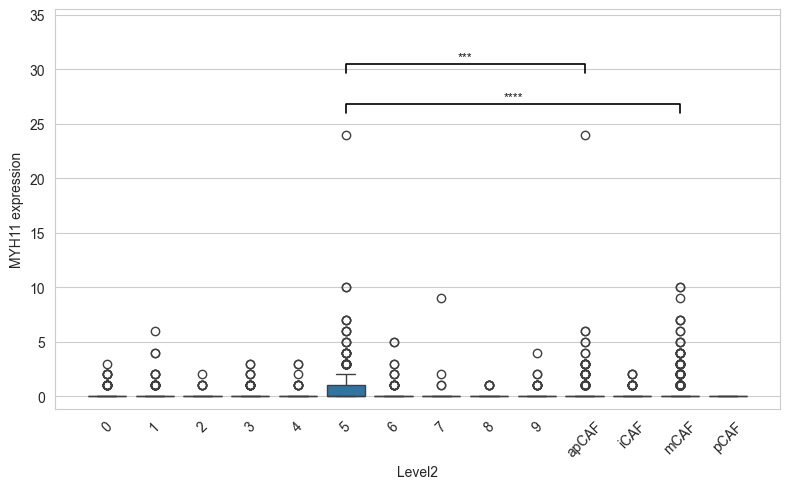

,group1,group2,n1,n2,median1,median2,U,p_raw,p_adjusted
0,5,mCAF,362,1267,0.0,0.0,268581.5,4.368817e-16,8.737634e-16
1,5,apCAF,362,376,0.0,0.0,75187.0,7.660174e-04,7.660174e-04


In [14]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

caf5_adata = sc_svc_expr.copy()
caf5_adata.obs['Level2'] = caf5_adata.obs["SVC_cluster"].copy()

sc_svc_exp_level2 = sc_svc_expr.copy()
select_adata = sc_svc_exp_level2.concatenate(caf5_adata)

plot_df = sc.get.obs_df(
  select_adata,
  keys=["Level2", "MYH11"],
  use_raw=False,
).dropna(subset=["Level2", "MYH11"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
  data=plot_df,
  x="Level2",
  y="MYH11",
  ax=ax,
)

comparisons = [
  ("5", "mCAF"),
  ("5", "apCAF"),
]

level2_text = plot_df["Level2"].astype(str)
available_groups = set(level2_text)

test_results = []

for group1, group2 in comparisons:
  values1 = plot_df.loc[
      level2_text == group1, "MYH11"
  ].to_numpy()

  values2 = plot_df.loc[
      level2_text == group2, "MYH11"
  ].to_numpy()

  statistic, p_value = mannwhitneyu(
      values1,
      values2,
      alternative="two-sided",
      method="auto",
  )

  test_results.append({
      "group1": group1,
      "group2": group2,
      "n1": len(values1),
      "n2": len(values2),
      "median1": float(pd.Series(values1).median()),
      "median2": float(pd.Series(values2).median()),
      "U": statistic,
      "p_raw": p_value,
  })

adjusted_p_values = multipletests(
  [result["p_raw"] for result in test_results],
  method="holm",
)[1]

for result, p_adjusted in zip(test_results, adjusted_p_values):
  result["p_adjusted"] = p_adjusted


def significance_label(p_value):
  if p_value < 1e-4:
      return "****"
  if p_value < 1e-3:
      return "***"
  if p_value < 1e-2:
      return "**"
  if p_value < 0.05:
      return "*"
  return "ns"

x_positions = {
  tick.get_text(): tick.get_position()[0]
  for tick in ax.get_xticklabels()
}

y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
bracket_height = 0.03 * y_range
bracket_step = 0.14 * y_range
base_y = y_max + 0.03 * y_range

for index, result in enumerate(test_results):
  group1 = result["group1"]
  group2 = result["group2"]
  p_adjusted = result["p_adjusted"]

  x1 = x_positions[group1]
  x2 = x_positions[group2]
  y = base_y + index * bracket_step

  ax.plot(
      [x1, x1, x2, x2],
      [y, y + bracket_height, y + bracket_height, y],
      color="black",
      linewidth=1.2,
  )

  ax.text(
      (x1 + x2) / 2,
      y + bracket_height,
      significance_label(p_adjusted),
      ha="center",
      va="bottom",
      fontsize=9,
  )

ax.set_ylim(
  y_min,
  base_y + len(test_results) * bracket_step + 0.08 * y_range,
)

ax.set_xlabel("Level2")
ax.set_ylabel("MYH11 expression")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

result_df = pd.DataFrame(test_results)
display(result_df)

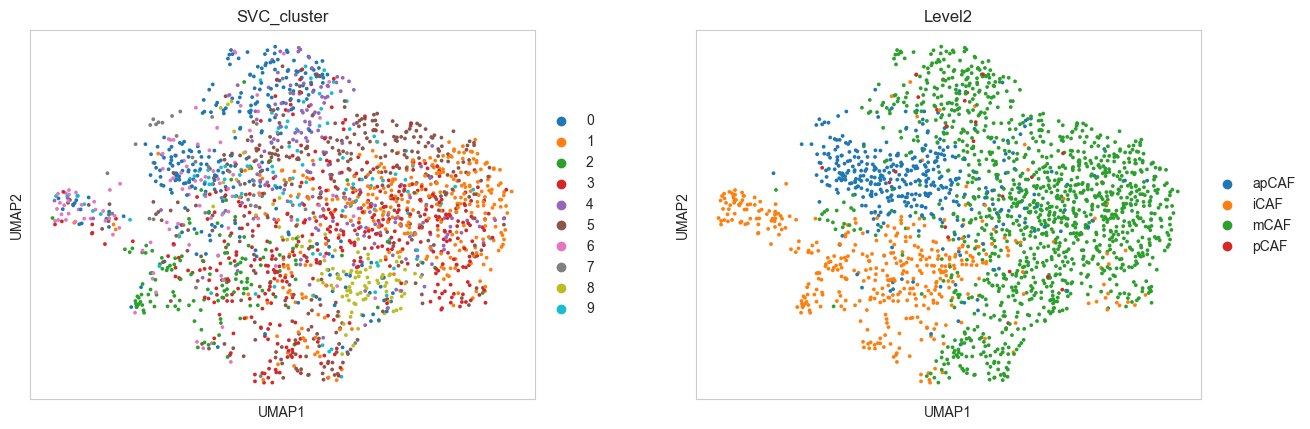

In [16]:
import scanpy as sc

plot_adata = sc_svc_expr.copy()
sc.pp.normalize_total(plot_adata, target_sum=1e4)
sc.pp.log1p(plot_adata)

sc.tl.pca(
  plot_adata,
  n_comps=50,
  svd_solver="arpack",
)

sc.pp.neighbors(
  plot_adata,
  n_neighbors=10,
  n_pcs=40,
)

sc.tl.umap(
  plot_adata,
  random_state=42,
)

sc.pl.umap(
  plot_adata,
  color=["SVC_cluster", "Level2"],
  ncols=2,
  size=30,
  wspace=0.2,
)

Conventional analysis fails to find CAF_5


expr_leiden_0.6: 4 clusters
expr_leiden_0.6
0    6457
1    5814
2    3484
3    1700
Name: count, dtype: int64

expr_leiden_0.8: 6 clusters
expr_leiden_0.8
0    4475
1    3473
2    3221
3    2576
4    1900
5    1810
Name: count, dtype: int64

expr_leiden_1.0: 7 clusters
expr_leiden_1.0
0    3375
1    2950
2    2905
3    2577
4    2095
5    1842
6    1711
Name: count, dtype: int64


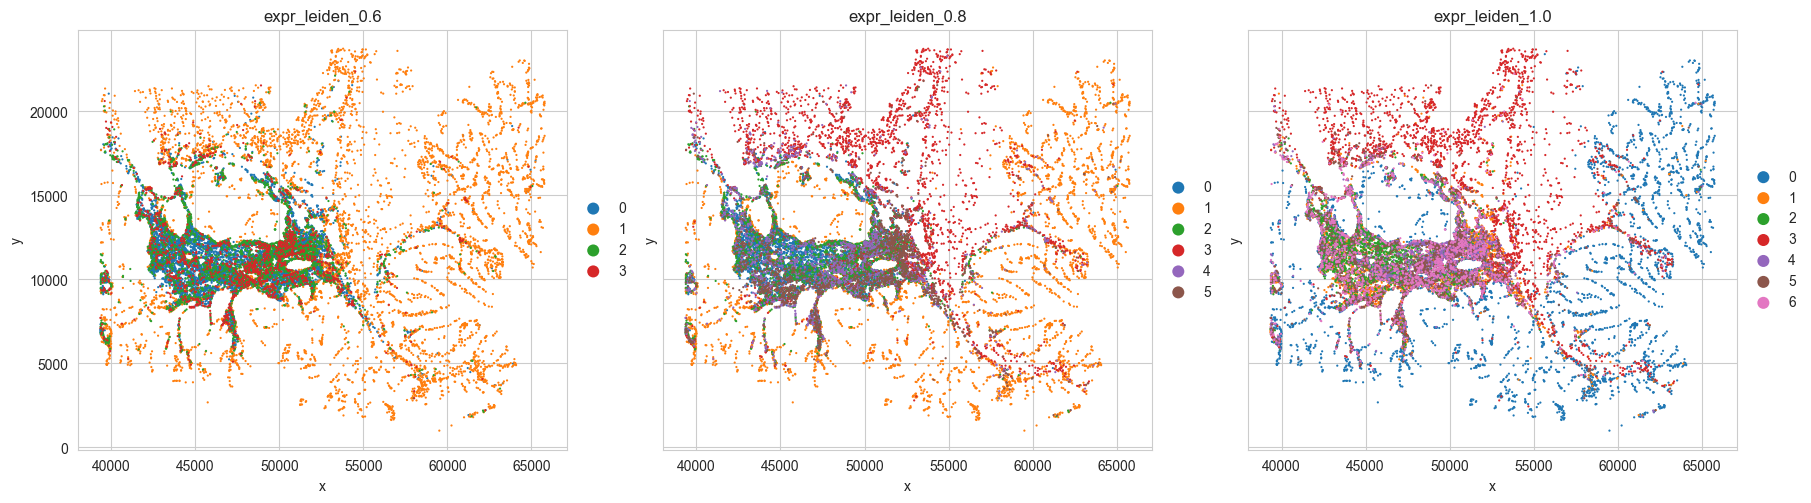

In [18]:
import os
import scanpy as sc
import matplotlib.pyplot as plt

cluster_adata = sc_svc_spatial.copy()
sc.pp.normalize_total(
  cluster_adata,
  target_sum=1e4,
)

sc.pp.log1p(cluster_adata)

n_comps = min(
  50,
  cluster_adata.n_obs - 1,
  cluster_adata.n_vars - 1,
)

sc.tl.pca(
  cluster_adata,
  n_comps=n_comps,
  svd_solver="arpack",
  random_state=42,
)

n_pcs = min(40, n_comps)

sc.pp.neighbors(
  cluster_adata,
  n_neighbors=10,
  n_pcs=n_pcs,
  use_rep="X_pca",
  random_state=42,
)
resolutions = [0.6, 0.8, 1.0]

leiden_keys = [
  f"expr_leiden_{resolution:.1f}"
  for resolution in resolutions
]

for resolution, key in zip(resolutions, leiden_keys):
  sc.tl.leiden(
      cluster_adata,
      resolution=resolution,
      key_added=key,
      random_state=42,
  )

  sc_svc_spatial.obs[key] = (
      cluster_adata.obs[key]
      .reindex(sc_svc_spatial.obs_names)
      .copy()
  )

for key in leiden_keys:
  cluster_counts = (
      sc_svc_spatial.obs[key]
      .value_counts()
      .sort_index()
  )

  print(f"\n{key}: {len(cluster_counts)} clusters")
  print(cluster_counts)

fig, axes = plt.subplots(
  nrows=1,
  ncols=3,
  figsize=(18, 6),
  sharex=True,
  sharey=True,
  constrained_layout=True,
)

for ax, key in zip(axes, leiden_keys):
  sc.pl.scatter(
      sc_svc_spatial,
      x="x",
      y="y",
      color=key,
      size=10,
      title=key,
      ax=ax,
      show=False,
  )

  ax.set_aspect(
      "equal",
      adjustable="box",
  )

plt.show()


In [25]:
cm_df = cluster_adata.obs.groupby(["SVC_cluster", f"expr_leiden_0.6"]).size().unstack(fill_value=0).T
df_pct = cm_df.div(cm_df.sum(axis=1), axis=0)
styled = (
    df_pct.style
    .format("{:.2%}")
    .highlight_max(axis=1, props="font-weight: bold;")
)
styled

SVC_cluster,0,1,2,3,4,5,6,7,8,9
expr_leiden_0.6,,,,,,,,,,
0,2.40%,32.99%,5.19%,20.74%,18.23%,16.26%,0.15%,0.68%,2.43%,0.93%
1,55.18%,0.07%,28.50%,0.50%,0.88%,1.12%,12.93%,0.29%,0.48%,0.05%
2,8.35%,12.72%,9.41%,26.49%,23.11%,6.31%,0.63%,0.86%,9.21%,2.90%
3,8.94%,10.41%,12.29%,9.53%,6.41%,4.06%,0.94%,40.29%,6.76%,0.35%


In [26]:
cm_df = cluster_adata.obs.groupby(["SVC_cluster", f"expr_leiden_0.8"]).size().unstack(fill_value=0).T
df_pct = cm_df.div(cm_df.sum(axis=1), axis=0)
styled = (
    df_pct.style
    .format("{:.2%}")
    .highlight_max(axis=1, props="font-weight: bold;")
)
styled

SVC_cluster,0,1,2,3,4,5,6,7,8,9
expr_leiden_0.8,,,,,,,,,,
0,1.30%,43.89%,3.75%,25.07%,16.89%,5.27%,0.02%,0.60%,2.37%,0.83%
1,90.35%,0.09%,0.32%,0.09%,3.34%,0.23%,5.04%,0.09%,0.40%,0.06%
2,5.68%,13.19%,7.51%,28.66%,23.72%,6.61%,0.50%,0.68%,10.21%,3.23%
3,4.74%,0.27%,67.24%,1.75%,0.54%,2.25%,21.89%,0.35%,0.89%,0.08%
4,10.05%,10.00%,14.42%,9.32%,6.58%,4.11%,1.63%,36.79%,6.79%,0.32%
5,6.30%,9.12%,5.64%,10.11%,20.28%,44.81%,0.72%,0.88%,1.10%,1.05%


In [27]:
cm_df = cluster_adata.obs.groupby(["SVC_cluster", f"expr_leiden_1.0"]).size().unstack(fill_value=0).T
df_pct = cm_df.div(cm_df.sum(axis=1), axis=0)
styled = (
    df_pct.style
    .format("{:.2%}")
    .highlight_max(axis=1, props="font-weight: bold;")
)
styled

SVC_cluster,0,1,2,3,4,5,6,7,8,9
expr_leiden_1.0,,,,,,,,,,
0,91.41%,0.06%,0.27%,0.15%,2.61%,0.33%,4.83%,0.09%,0.24%,0.03%
1,3.80%,19.25%,5.19%,17.02%,20.64%,30.37%,0.34%,0.75%,1.97%,0.68%
2,1.38%,49.19%,3.13%,24.34%,15.73%,3.37%,0.00%,0.52%,1.27%,1.07%
3,4.70%,0.31%,67.52%,1.44%,0.35%,2.10%,22.24%,0.50%,0.78%,0.08%
4,4.96%,16.85%,8.88%,22.10%,24.01%,6.21%,0.48%,0.67%,11.41%,4.44%
5,10.59%,11.56%,11.02%,9.23%,6.35%,4.45%,1.74%,37.62%,7.06%,0.38%
6,8.71%,10.58%,8.59%,33.26%,20.98%,7.77%,0.70%,0.94%,7.54%,0.94%


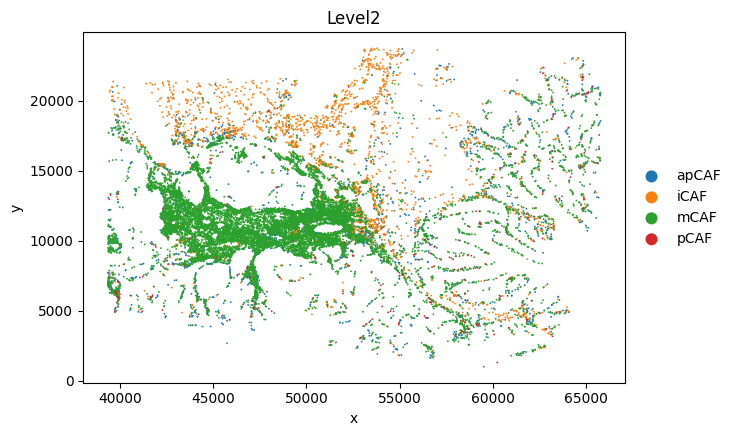

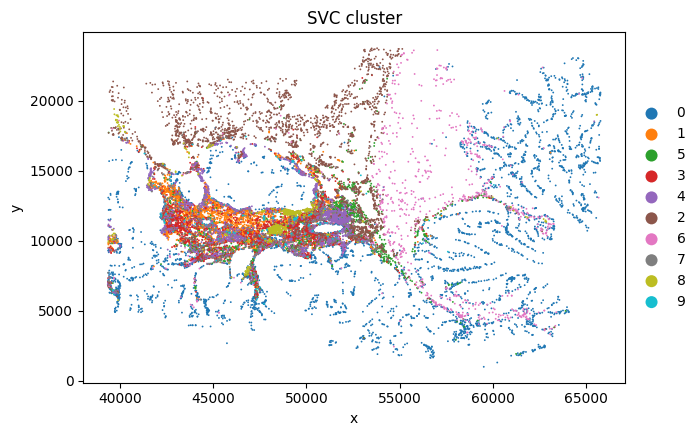

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

size = None
cmap = plt.cm.get_cmap('tab20', lut=10)
palette = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='Level2',
              size=size)
desired_order = ['0', '1', '5', '3', '4', '2', '6', '7', '8', '9']  # for better visualization
current_categories = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in desired_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'] = (
    sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.reorder_categories(ordered_categories, ordered=True)
)
sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='SVC_cluster',
              size=size)

## Where are the reconstructed CAF states located?

**Method and figure reading.** The spatial-side maps color the same Xenium coordinates first by expert `Level2` annotation and then by sc-SVC cluster. Separate and side-by-side figures are retained to orient the later subtype-specific analyses.

**Direct observation.** Multiple CAF clusters occupy overlapping but non-identical regions in this specimen. These displays show spatial association; they do not quantify proximity, invasion, or mechanism.

**Interpretation boundary.** The global map is an orientation view. Marker-informed state labels and the rationale for focal follow-up are assigned only after the all-cluster evidence review below.


<Figure size 1000x800 with 0 Axes>

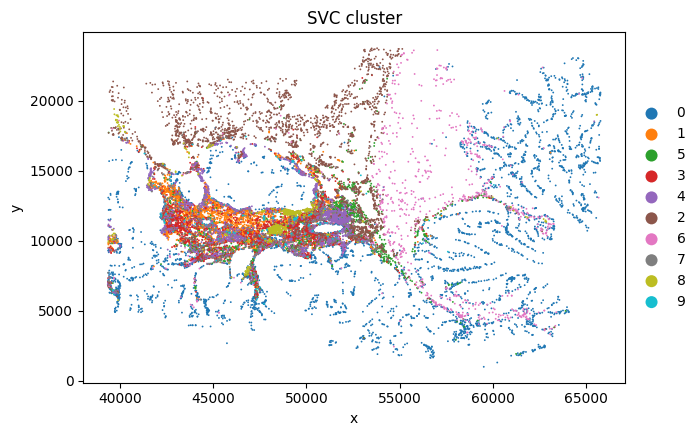

<Figure size 1000x1600 with 0 Axes>

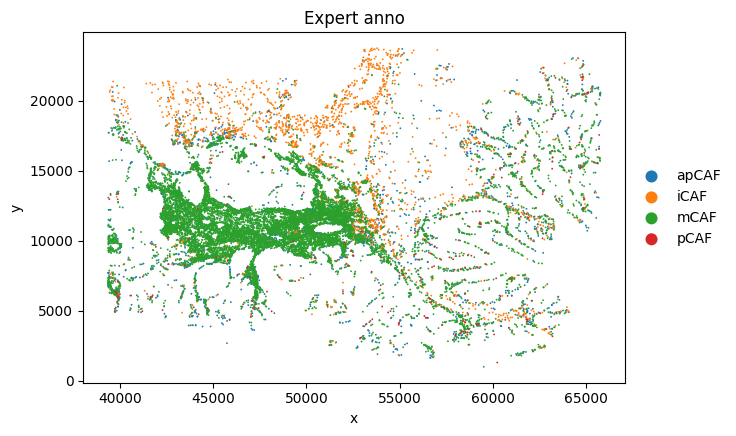

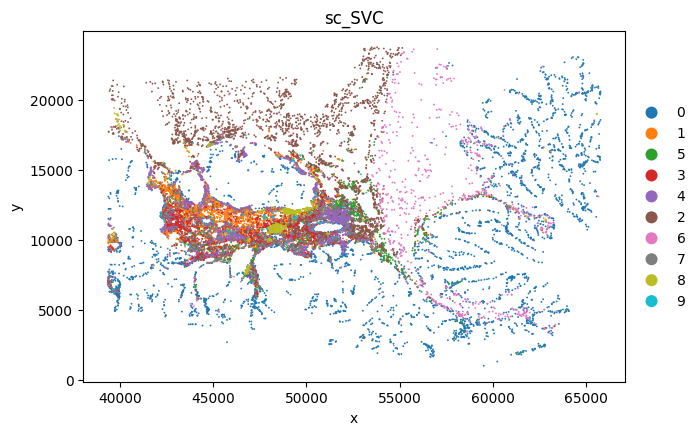

In [6]:
import matplotlib.pyplot as plt
def plot_sc_SVC(adata, color, title = None, file_name = None):

    colors = color if isinstance(color, (list, tuple)) else [color]
    titles = title if isinstance(title, (list, tuple)) else [title] * len(colors)
    plt.figure(figsize=(10, 8*len(colors)))
    for color_key, plot_title in zip(colors, titles):
        sc.pl.scatter(
            adata, x="x", y="y",
            color=color_key,
            title=plot_title, show=False,
        )
    plt.savefig(file_name, dpi = 300)
    plt.show()
    plt.close()

sc_SVC_file_name = f"{output_dir}/sc_SVC.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color='SVC_cluster',
            file_name=sc_SVC_file_name
            )

sc_SVC_file_name = f"{output_dir}/compare.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color=['Level2','SVC_cluster'],
            title=["Expert anno", "sc_SVC"],
            file_name=sc_SVC_file_name
            )

## Evidence collection across all reconstructed CAF/stromal clusters

**Question.** Before selecting focal CAF states and a normal-infiltrated comparator, what marker and spatial evidence is present across all ten reconstructed clusters?

**Analysis sequence.** The full differential table is retained as supporting evidence. Curated marker programs are then reviewed for every expression-side cluster, followed immediately by conservative identity annotations and spatial small multiples for every spatial-side cluster. The two H5AD objects share phenotype semantics but contain different, non-observation-paired cells.


In [7]:
all_cluster_nums = [str(i) for i in range(10)]
spatial_cluster = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].astype(str)
spatial_counts = spatial_cluster.value_counts().reindex(all_cluster_nums, fill_value=0)

## Supporting all-cluster differential table

The full table is retained as supporting evidence before the marker and spatial review below. It is broader than the curated marker panel and does not itself determine focal selection.


In [8]:
sc_svc_analysis.sc_SVC_degs.to_csv(f"{output_dir}/degs_all.csv")
sc_svc_analysis.sc_SVC_degs

,group,gene,logfoldchanges,pvals,pvals_adj,log_q
0,3,C3,4.284732,2.006540e-242,2.626159e-238,100.000000
1,1,TIMP3,3.870138,8.797010e-79,1.151353e-74,73.938792
2,5,TAGLN,3.033704,1.085612e-76,1.420849e-72,71.847452
3,1,COMP,5.330997,4.945399e-76,3.236269e-72,71.489955
4,2,INHBA,-4.796747,7.599558e-71,9.946301e-67,66.002338
...,...,...,...,...,...,...
130875,8,C4BPB,0.000000,1.000000e+00,1.000000e+00,-0.000000
130876,8,IL26,0.000000,1.000000e+00,1.000000e+00,-0.000000
130877,8,TM4SF20,0.000000,1.000000e+00,1.000000e+00,-0.000000
130878,8,NOS3,0.000000,1.000000e+00,1.000000e+00,-0.000000


### Marker evidence across all clusters

**Method.** The curated panel is plotted for every expression-side cluster before any focal selection. No markers are recalculated after restricting to focal states and the comparator.

**How to read the figure.** Dot size and color summarize expression among expression-side cells assigned to each cluster. The plot retains neutral Cluster 0–Cluster 9 labels; the marker-informed identity annotations follow immediately below.


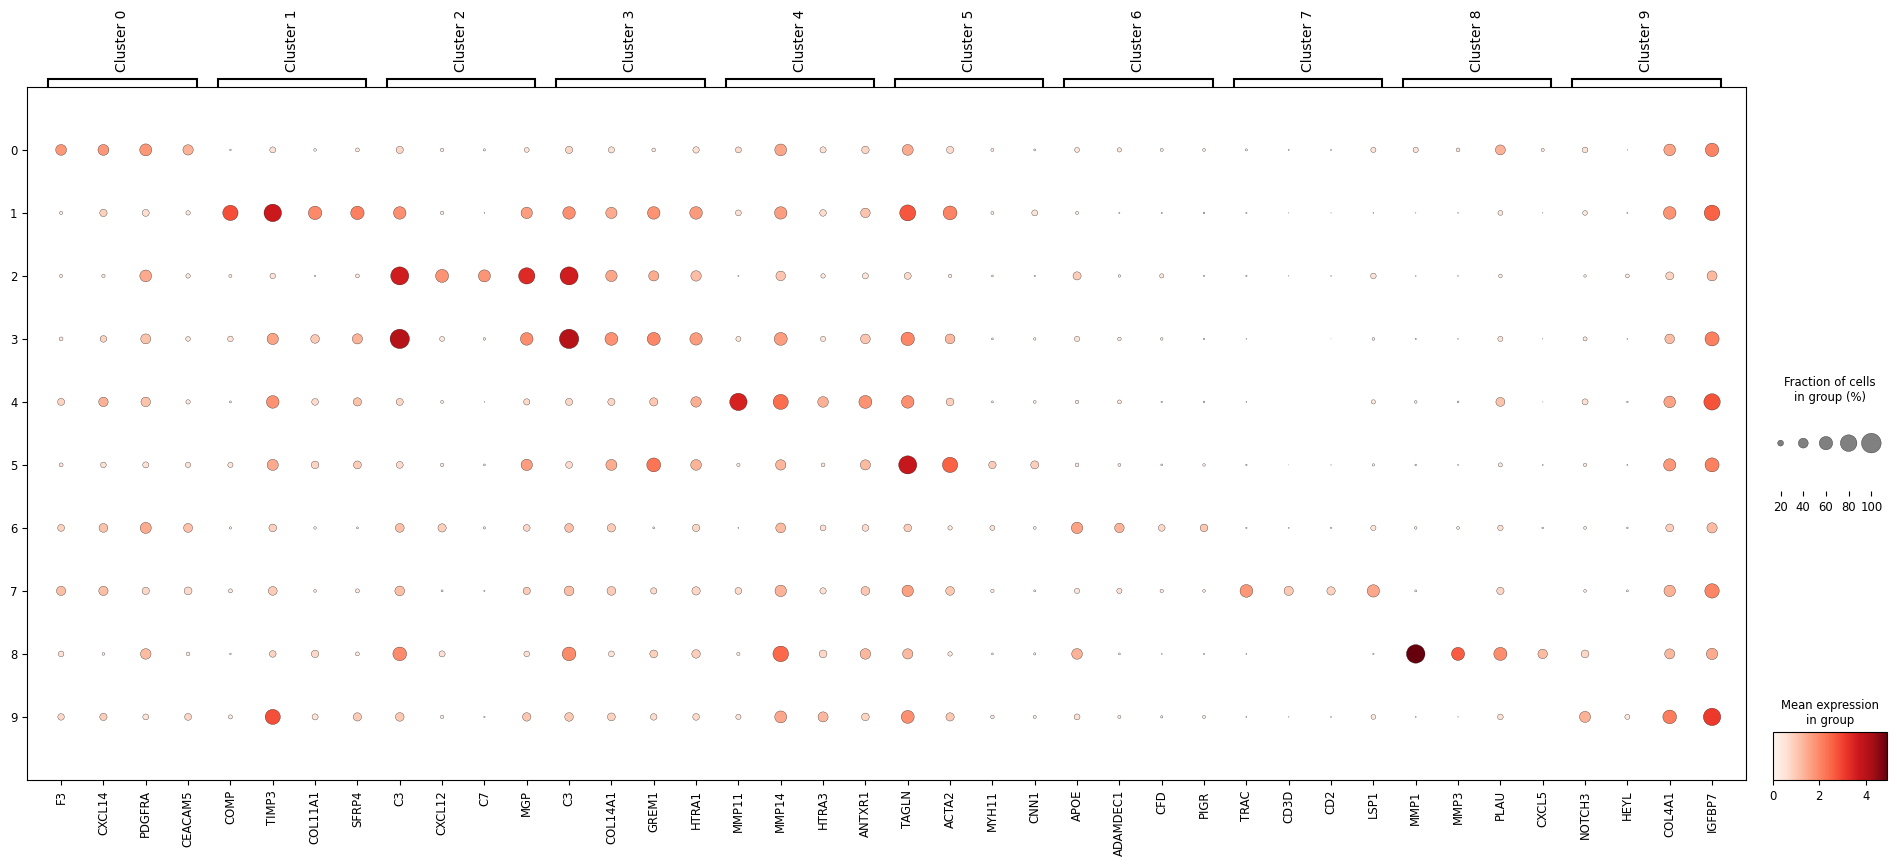

In [9]:
import matplotlib.pyplot as plt

all_cluster_marker_panels = {
    'Cluster 0': ['F3', 'CXCL14', 'PDGFRA', 'CEACAM5'],
    'Cluster 1': ['COMP', 'TIMP3', 'COL11A1', 'SFRP4'],
    'Cluster 2': ['C3', 'CXCL12', 'C7', 'MGP'],
    'Cluster 3': ['C3', 'COL14A1', 'GREM1', 'HTRA1'],
    'Cluster 4': ['MMP11', 'MMP14', 'HTRA3', 'ANTXR1'],
    'Cluster 5': ['TAGLN', 'ACTA2', 'MYH11', 'CNN1'],
    'Cluster 6': ['APOE', 'ADAMDEC1', 'CFD', 'PIGR'],
    'Cluster 7': ['TRAC', 'CD3D', 'CD2', 'LSP1'],
    'Cluster 8': ['MMP1', 'MMP3', 'PLAU', 'CXCL5'],
    'Cluster 9': ['NOTCH3', 'HEYL', 'COL4A1', 'IGFBP7'],
}
marker_adata = sc_svc_analysis.sc_SVC_adata_expr[
    sc_svc_analysis.sc_SVC_adata_expr.obs['SVC_cluster'].astype(str).isin(all_cluster_nums)
].copy()
marker_adata.obs['SVC_cluster'] = pd.Categorical(
    marker_adata.obs['SVC_cluster'].astype(str),
    categories=all_cluster_nums,
    ordered=True,
)
sc.pp.normalize_total(marker_adata, target_sum=1e4)
sc.pp.log1p(marker_adata)
marker_dotplot = sc.pl.dotplot(
    marker_adata,
    all_cluster_marker_panels,
    groupby='SVC_cluster',
    categories_order=all_cluster_nums,
    dendrogram=False,
    figsize=(24, 9),
    show=False,
    return_fig=True,
)
marker_dotplot.show()
plt.close('all')

## Marker-informed identity annotations

The displayed marker programs support the conservative functional/state annotations below. They are descriptions of reconstructed marker programs, not independent lineage validation or a cluster-quality ranking. Cluster 7 is retained as a T-cell-marker-rich mixed cluster rather than being forced into a pure CAF identity.

All-cluster pathway enrichment is not added because unevenly returned terms would not improve the shared marker-based interpretation. The existing focal pathway analysis remains below, after focal selection.


In [10]:
all_cluster_annotations = pd.DataFrame(
    {
        'Cluster': all_cluster_nums,
        'Functional/state annotation': [
            'F3/CXCL14+ fibroblast-like',
            'COMP/COL11A1+ ECM-remodeling CAF',
            'CXCL12/C7+ inflammatory-complement fibroblast-like',
            'COL14A1/C3+ matrix-support fibroblast-like',
            'MMP11/HTRA3+ immune-regulatory/proteolytic CAF',
            'ACTA2/MYH11+ contractile SMC-like CAF',
            'ADAMDEC1/APOE+ immune-associated fibroblast-like',
            'T-cell-marker-rich mixed cluster',
            'MMP1/MMP3+ ECM-breakdown inflammatory CAF',
            'NOTCH3/HEYL+ perivascular/mural-like fibroblast',
        ],
        'Representative markers': [
            ', '.join(all_cluster_marker_panels[f'Cluster {cluster}'])
            for cluster in all_cluster_nums
        ],
    }
)
all_cluster_annotations.set_index('Cluster')

,Functional/state annotation,Representative markers
Cluster,,
0,F3/CXCL14+ fibroblast-like,"F3, CXCL14, PDGFRA, CEACAM5"
1,COMP/COL11A1+ ECM-remodeling CAF,"COMP, TIMP3, COL11A1, SFRP4"
2,CXCL12/C7+ inflammatory-complement fibroblast-...,"C3, CXCL12, C7, MGP"
3,COL14A1/C3+ matrix-support fibroblast-like,"C3, COL14A1, GREM1, HTRA1"
4,MMP11/HTRA3+ immune-regulatory/proteolytic CAF,"MMP11, MMP14, HTRA3, ANTXR1"
5,ACTA2/MYH11+ contractile SMC-like CAF,"TAGLN, ACTA2, MYH11, CNN1"
6,ADAMDEC1/APOE+ immune-associated fibroblast-like,"APOE, ADAMDEC1, CFD, PIGR"
7,T-cell-marker-rich mixed cluster,"TRAC, CD3D, CD2, LSP1"
8,MMP1/MMP3+ ECM-breakdown inflammatory CAF,"MMP1, MMP3, PLAU, CXCL5"


### Spatial localization across all clusters

**Method and figure reading.** Each panel highlights one spatial-side cluster while all other CAF/stromal cells remain gray. All panels share the same coordinates, limits, and aspect ratio, so this is a qualitative comparison of localization rather than a region-enrichment statistic.

**Direct observation.** The small multiples provide the spatial evidence for every cluster before focal states and the comparator are selected.


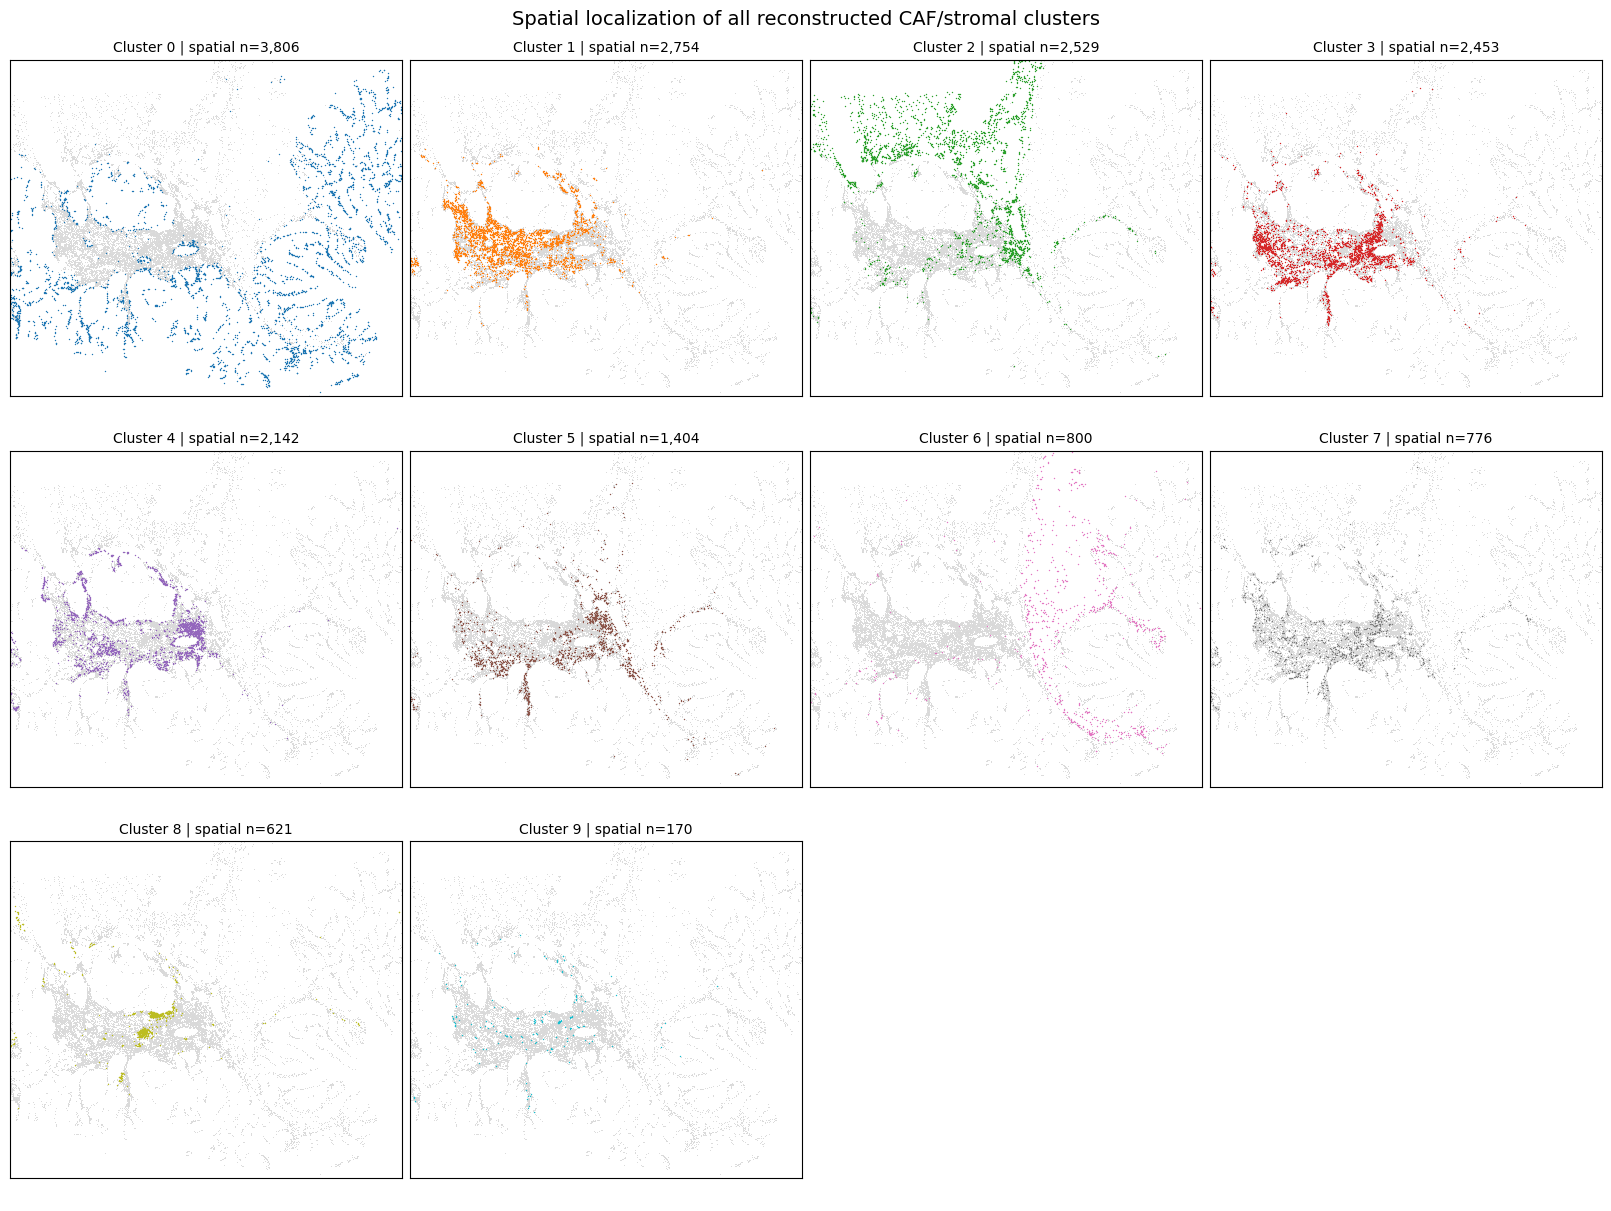

In [11]:
spatial_adata = sc_svc_analysis.sc_SVC_adata_spatial
spatial_x = spatial_adata.obs['x'].to_numpy()
spatial_y = spatial_adata.obs['y'].to_numpy()
spatial_cluster_labels = spatial_adata.obs['SVC_cluster'].astype(str).to_numpy()
spatial_xlim = (spatial_x.min(), spatial_x.max())
spatial_ylim = (spatial_y.min(), spatial_y.max())
cluster_colors = {
    cluster: plt.cm.tab10(index)
    for index, cluster in enumerate(all_cluster_nums)
}

fig, axes = plt.subplots(3, 4, figsize=(16, 12), constrained_layout=True)
for ax, cluster in zip(axes.flat, all_cluster_nums):
    target = spatial_cluster_labels == cluster
    ax.scatter(spatial_x, spatial_y, s=0.45, c='#d9d9d9', linewidths=0, rasterized=True)
    ax.scatter(
        spatial_x[target],
        spatial_y[target],
        s=1.0,
        c=cluster_colors[cluster],
        linewidths=0,
        rasterized=True,
    )
    ax.set_title(f"Cluster {cluster} | spatial n={spatial_counts.loc[cluster]:,}", fontsize=10)
    ax.set_xlim(spatial_xlim)
    ax.set_ylim(spatial_ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])

for ax in list(axes.flat)[len(all_cluster_nums):]:
    ax.set_axis_off()
fig.suptitle('Spatial localization of all reconstructed CAF/stromal clusters', fontsize=14)
plt.show()
plt.close(fig)

## Integrated all-cluster summary and focal selection

**Integrated interpretation.** The table below combines the marker-informed annotations with the spatial review after every cluster has been examined. It retains only the evidence needed to explain the focal selection and the normal-infiltrated comparator.

**Spatial/paper-context labels.** An em dash indicates that no paper-facing context is assigned here. It does not indicate lower quality, absent localization, or absent marker interpretability.


In [12]:
spatial_contexts = {
    '0': '—',
    '1': 'ECM-remodeling focus / paper CAF_1',
    '2': '—',
    '3': '—',
    '4': 'Immune-regulatory/proteolytic focus / paper CAF_4',
    '5': 'SMC-associated stromal context / paper CAF_5',
    '6': 'Normal-infiltrated comparator / paper CAF_6',
    '7': '—',
    '8': 'Tumor-adjacent invasive-front ECM-breakdown context / paper CAF_8',
    '9': '—',
}
all_cluster_summary = all_cluster_annotations.assign(
    **{'Spatial/paper context': all_cluster_annotations['Cluster'].map(spatial_contexts)}
)
all_cluster_summary

,Cluster,Functional/state annotation,Representative markers,Spatial/paper context
0,0,F3/CXCL14+ fibroblast-like,"F3, CXCL14, PDGFRA, CEACAM5",—
1,1,COMP/COL11A1+ ECM-remodeling CAF,"COMP, TIMP3, COL11A1, SFRP4",ECM-remodeling focus / paper CAF_1
2,2,CXCL12/C7+ inflammatory-complement fibroblast-...,"C3, CXCL12, C7, MGP",—
3,3,COL14A1/C3+ matrix-support fibroblast-like,"C3, COL14A1, GREM1, HTRA1",—
4,4,MMP11/HTRA3+ immune-regulatory/proteolytic CAF,"MMP11, MMP14, HTRA3, ANTXR1",Immune-regulatory/proteolytic focus / paper CAF_4
5,5,ACTA2/MYH11+ contractile SMC-like CAF,"TAGLN, ACTA2, MYH11, CNN1",SMC-associated stromal context / paper CAF_5
6,6,ADAMDEC1/APOE+ immune-associated fibroblast-like,"APOE, ADAMDEC1, CFD, PIGR",Normal-infiltrated comparator / paper CAF_6
7,7,T-cell-marker-rich mixed cluster,"TRAC, CD3D, CD2, LSP1",—
8,8,MMP1/MMP3+ ECM-breakdown inflammatory CAF,"MMP1, MMP3, PLAU, CXCL5",Tumor-adjacent invasive-front ECM-breakdown co...
9,9,NOTCH3/HEYL+ perivascular/mural-like fibroblast,"NOTCH3, HEYL, COL4A1, IGFBP7",—


### Why clusters 1, 4, 5, and 8 are focal CAF states

The choice is made after the full ten-cluster review, with coverage of non-redundant stromal programs and the existing paper-facing contexts as the primary criterion. Cluster 6 is retained only as the normal-infiltrated comparator, not as a fifth focal CAF program.

| Focal cluster | Integrated cellular/state evidence | Paper-facing context | Follow-up role |
| --- | --- | --- | --- |
| 1 | COMP/COL11A1+ ECM-remodeling CAF: COMP, TIMP3, COL11A1, SFRP4 | ECM-remodeling focus | paper CAF_1 |
| 4 | MMP11/HTRA3+ immune-regulatory/proteolytic CAF: MMP11, MMP14, HTRA3, ANTXR1 | Immune-regulatory/proteolytic focus | paper CAF_4 |
| 5 | ACTA2/MYH11+ contractile SMC-like CAF: TAGLN, ACTA2, MYH11, CNN1 | SMC-associated stromal context | paper CAF_5 |
| 8 | MMP1/MMP3+ ECM-breakdown inflammatory CAF: MMP1, MMP3, PLAU, CXCL5 | Tumor-adjacent invasive-front ECM-breakdown context | paper CAF_8 |

**Scope of the follow-up.** Clusters 1, 4, 5, and 8 were not selected by cluster size, assignment posterior, DEG yield, or apparent interpretability. Cluster 6 is used for the normal-infiltrated comparison. Clusters 0, 2, 3, 7, and 9 received the same marker and spatial review; not being focal does not mean they are lower quality or unidentifiable. Cluster 7 remains a T-cell-marker-rich mixed cluster rather than a forced pure CAF identity. The later CAF_8–Tumor, CAF_4–Tumor, and CAF_5–SMC blocks each address their selected focal hypothesis.


In [13]:
# Defined only after the integrated ten-cluster evidence synthesis above.
focal_cluster_nums = ['1', '4', '5', '8']
normal_comparator_cluster = '6'
analysis_cluster_nums = sorted(
    focal_cluster_nums + [normal_comparator_cluster],
    key=int,
)

## Which marker programs distinguish the focal CAF states?

**Method and figure reading.** The automatic dot plot presents top data-driven DEGs as supporting evidence. CAF_6 (cluster 6 here) is the normal-infiltrated comparator in the paper-facing panel; the curated program panel focuses on ECM-remodeling cluster 1, immune-regulatory cluster 4, SMC-like cluster 5, and ECM-breakdown cluster 8. The printed gene list and first unsaved view are retained as collapsible technical evidence; the saved dot plot is the main presentation.

**Direct observation.** The displayed marker programs distinguish the four focal clusters within the reconstructed CAF compartment.

**Paper context.** The paper labels these states CAF_1 ECM-remodeling, CAF_4 immune regulatory, CAF_5 SMC-like, and CAF_8 ECM-breakdown. Clinical, invasion, and lineage interpretations require the paper's additional cohorts and experiments.


Conducting differential expression analysis...


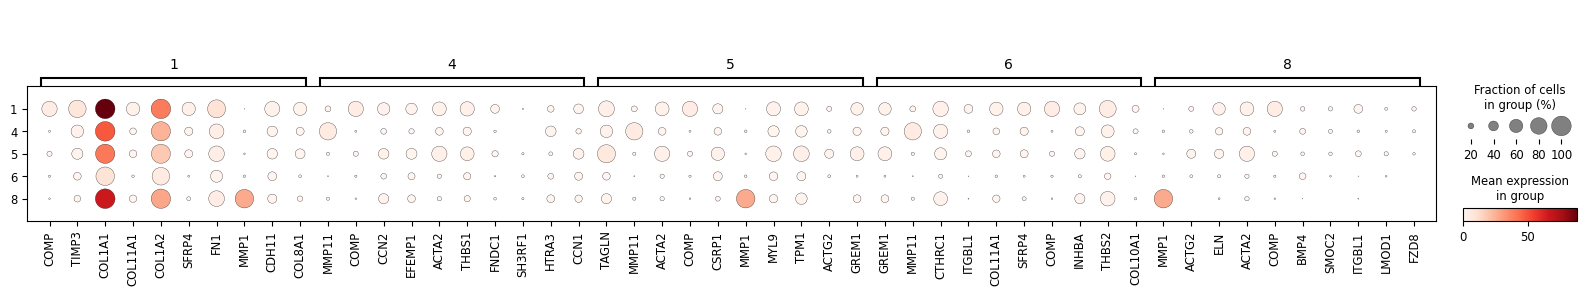

In [14]:
cluster_nums = analysis_cluster_nums

degs = sc_svc_analysis.get_svc_degs(cluster_nums)
marker_dict = (
    degs.groupby('group')['gene']
    .apply(lambda x: x.head(10).tolist())
    .to_dict()
)
sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict)

In [15]:
for i,j in marker_dict.items():
    print(i, j)

1 ['COMP', 'TIMP3', 'COL1A1', 'COL11A1', 'COL1A2', 'SFRP4', 'FN1', 'MMP1', 'CDH11', 'COL8A1']
4 ['MMP11', 'COMP', 'CCN2', 'EFEMP1', 'ACTA2', 'THBS1', 'FNDC1', 'SH3RF1', 'HTRA3', 'CCN1']
5 ['TAGLN', 'MMP11', 'ACTA2', 'COMP', 'CSRP1', 'MMP1', 'MYL9', 'TPM1', 'ACTG2', 'GREM1']
6 ['GREM1', 'MMP11', 'CTHRC1', 'ITGBL1', 'COL11A1', 'SFRP4', 'COMP', 'INHBA', 'THBS2', 'COL10A1']
8 ['MMP1', 'ACTG2', 'ELN', 'ACTA2', 'COMP', 'BMP4', 'SMOC2', 'ITGBL1', 'LMOD1', 'FZD8']


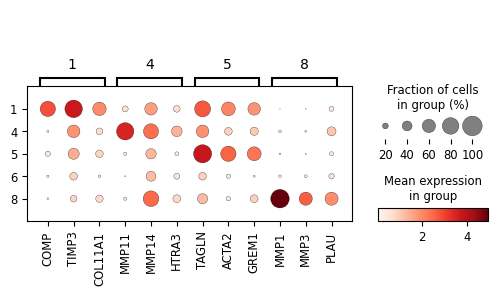

In [16]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.useafm'] = False

marker_dict = {
    "1": ['COMP', 'TIMP3', 'COL11A1'], # ECM-Architect	
    "4": ['MMP11',  # Inflamed-Proteolytic
          'MMP14', 'HTRA3'],
    "5": ['TAGLN', 'ACTA2', 'GREM1', #  SMC-like CAF	
          ],
    "8": ['MMP1', 'MMP3', 'PLAU', # ECM-Destructive	desCAF	
          ]
    }

sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict, normalize=True)

<Figure size 800x600 with 0 Axes>

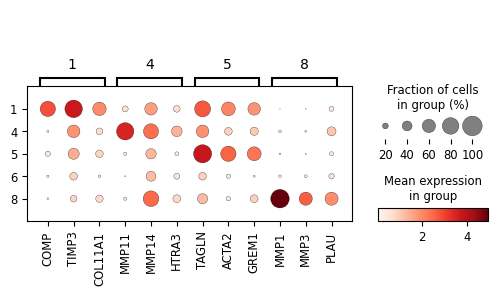

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(8, 6))
sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict, normalize=True)
plt.savefig(f"{output_dir}/sc_SVC_dotplot.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Which functional programs characterize the focal CAF states?

**Method.** Cluster-specific DEGs are enriched against frozen local Hallmark, KEGG 2021 Human, and GO Biological Process 2025 GMT files through GSEApy. The violin output provides supporting marker-distribution context; per-cluster bar and network plots retain the full exploratory view, while the curated composite selects terms used in the paper-facing comparison.

**Figure reading.** Larger `-log10(Adjusted P-value)` bars indicate stronger statistical enrichment in the returned table. A zero in the curated composite means that the term was not returned for that group in this run; it does not mean the pathway has zero biological activity.

**Direct observation.** The four focal clusters return different sets of ECM, inflammatory, contractile, and matrix-organization terms under the frozen resources.

**Paper context.** The paper uses these terms to describe non-redundant CAF programs. The frozen local analysis supports executable reproduction but is not asserted to be scientifically identical to the historical online resource versions.


In [18]:
cluster_nums

['1', '4', '5', '6', '8']

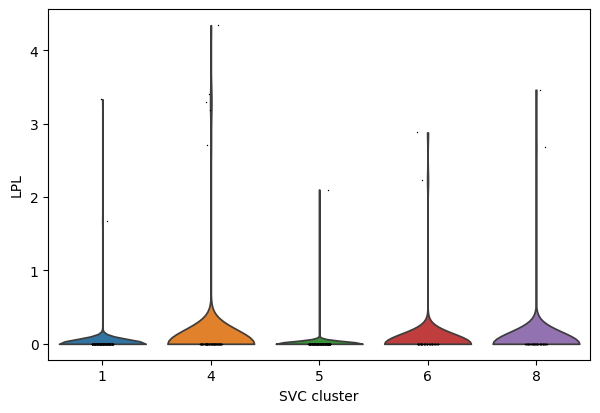

In [19]:
sc_svc_analysis.get_violin_plot(cluster_nums, True)

In [20]:
from datetime import datetime, timezone
import hashlib
import json
from pathlib import Path

fc_threshold = 1
pathway_num = 20
gene_num = 60
geneset_file = [
    "./pathway/h.all.v2025.1.Hs.symbols.gmt",
    "./pathway/KEGG_2021_Human.gmt",
    "./pathway/GO_Biological_Process_2025.gmt",
]
resource_ids = ["hallmark_gmt", "kegg_2021_human_gmt", "go_biological_process_2025_gmt"]
resource_paths = [
    "reproduce/case/pathway/h.all.v2025.1.Hs.symbols.gmt",
    "reproduce/case/pathway/KEGG_2021_Human.gmt",
    "reproduce/case/pathway/GO_Biological_Process_2025.gmt",
]
local_resources = [
    {"id": resource_id, "path": resource_path, "sha256": hashlib.sha256(Path(gmt_path).read_bytes()).hexdigest()}
    for resource_id, resource_path, gmt_path in zip(resource_ids, resource_paths, geneset_file)
]
pathway_file_name = f"{output_dir}/pathway_{fc_threshold}_{pathway_num}.txt"
local_started_at = datetime.now(timezone.utc).isoformat()
all_pathway = sc_svc_analysis.get_pathway_conclusion(
    cluster_nums, fc_threshold=fc_threshold, pathway_num=pathway_num, gene_num=gene_num, geneset_file=geneset_file, normalize=True)
all_pathway.to_csv(f"{output_dir}/enrichment.csv", index=False)
Path(f"{output_dir}/fib-integration-evidence.json").write_text(
    json.dumps({
        "provider": "GSEApy local enrich",
        "background": None,
        "background_policy": "GSEApy default over local GMT union",
        "resources": local_resources,
        "runs": [{
            "analysis": "pathway_conclusion",
            "started_at": local_started_at,
            "completed_at": datetime.now(timezone.utc).isoformat(),
        }],
    }, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)

Conducting differential expression analysis...


Cluster 1: 
Up-regulated genes: ['COMP', 'TIMP3', 'COL1A1', 'COL11A1', 'COL1A2', 'SFRP4', 'FN1', 'CDH11', 'COL8A1', 'SFRP2', 'THBS2', 'IGFBP3', 'COL5A1', 'ELN', 'SPARC', 'C3', 'ITGBL1', 'SERPINE2', 'CTHRC1', 'PRSS23', 'BGN', 'CDKN2B', 'ISLR', 'COL6A3', 'FNDC1', 'PLXDC2', 'COL10A1', 'FBLN2', 'MFAP5', 'VCAN', 'AEBP1', 'ITGA11', 'ADAM12', 'LOXL1', 'SEMA3C', 'COL16A1', 'C1QTNF3', 'MATN3', 'THBS1', 'LRP1', 'SPON1', 'CCN2', 'PRELP', 'SLC44A1', 'TIMP1', 'CD248', 'CKAP4', 'ENC1', 'COL15A1', 'EFEMP1', 'SLC12A8', 'PPIC', 'ANOS1', 'SDC2', 'ASPN', 'MGP', 'LAMP5', 'HSPG2', 'TSPAN2', 'FZD8']
Enriched pathways: ['HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION'
 'Protein digestion and absorption' 'ECM-receptor interaction'
 'Extracellular Matrix Organization (GO:0030198)'
 'Skeletal System Development (GO:0001501)'
 'Extracellular Structure Organization (GO:0043062)'
 'External Encapsulating Structure Organization (GO:0045229)'
 'Focal adhesion' 'Proteoglycans in cancer' 'Malaria'
 'Collagen Fibril Organi

Cluster 4: 
Up-regulated genes: ['MMP11', 'HTRA3', 'MMP14', 'DKK3', 'ANTXR1', 'IGFBP7', 'B2M', 'GRN', 'CTSB', 'CXCL14', 'PLAT', 'ISLR', 'NID1', 'ECM1', 'BST2', 'PLAU', 'ST5', 'ITIH5', 'PDPN', 'A2M', 'PCDH18', 'PAG1', 'F3', 'BMP8A', 'FXYD6', 'OPTN', 'GPC1', 'TCF4', 'F2R', 'ARL4C', 'CPXM1', 'ABCC4', 'COCH', 'LSP1', 'NSG1', 'PSMB8', 'WNT5A', 'APCDD1', 'COL7A1', 'ALCAM', 'PLXDC1', 'TNFRSF21', 'IFI30', 'AGT', 'PTPRS', 'OLFML2A', 'FOXF1', 'TMEM158', 'WNT4', 'SLC16A1', 'NUDT2', 'NOTCH3', 'TM4SF1', 'FOXQ1', 'CD82', 'PCF11', 'TSR3', 'RIN2', 'ETS1', 'NDNF']
Enriched pathways: ['Positive Regulation of Blood Coagulation (GO:0030194)'
 'Positive Regulation of Cell Migration (GO:0030335)'
 'Complement and coagulation cascades' 'HALLMARK_COAGULATION'
 'Positive Regulation of Response to External Stimulus (GO:0032103)'
 'Positive Regulation of Vasculature Development (GO:1904018)'
 'Positive Regulation of Angiogenesis (GO:0045766)'
 'Regulation of Endothelial Cell Migration (GO:0010594)'
 'Positive Re

Cluster 8: 
Up-regulated genes: ['MMP1', 'MMP3', 'PLAU', 'CHI3L1', 'CXCL5', 'FAM20C', 'COL6A1', 'IL7R', 'SOD2', 'COL3A1', 'APOE', 'CXCL1', 'POSTN', 'PCOLCE', 'MMP14', 'FTH1', 'PDPN', 'PRRX1', 'C3', 'CTSK', 'CXCL6', 'FBLN2', 'MME', 'MMP9', 'COL7A1', 'STEAP1', 'FAP', 'RIPOR3', 'TDO2', 'ADAMTS2', 'CEBPB', 'CA12', 'SAT1', 'PLK2', 'EPAS1', 'TSPAN11', 'SULF2', 'MXRA5', 'SDK1', 'SPHK1', 'BMP1', 'ADRA2A', 'CD82', 'DIO2', 'ANGPTL2', 'NOTCH3', 'ITGA5', 'RARRES2', 'CCDC71L', 'ICAM1', 'LAPTM4B', 'CYP7B1', 'PTPRU', 'WNT5A', 'SLC16A3', 'CHST15', 'COL5A3', 'ADM', 'MT2A', 'RNF144A']
Enriched pathways: ['HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION'
 'Extracellular Matrix Organization (GO:0030198)'
 'Extracellular Structure Organization (GO:0043062)'
 'External Encapsulating Structure Organization (GO:0045229)'
 'TNF signaling pathway' 'Collagen Catabolic Process (GO:0030574)'
 'Endodermal Cell Differentiation (GO:0035987)' 'IL-17 signaling pathway'
 'Rheumatoid arthritis' 'Endoderm Formation (GO:0001706

Cluster 5: 
Up-regulated genes: ['TAGLN', 'ACTA2', 'CSRP1', 'MYL9', 'TPM1', 'ACTG2', 'GREM1', 'MYLK', 'MYH11', 'DES', 'TPM2', 'THBS1', 'CNN1', 'CALD1', 'HSPB1', 'SORBS1', 'FLNA', 'CRYAB', 'LPP', 'MYL6', 'PPP1R12B', 'CCN1', 'SYNPO2', 'FLNC', 'TGFBR1', 'ALKAL1', 'MAP4', 'PLN', 'LBH', 'MGP', 'ENAH', 'CLU', 'MCAM', 'LIMA1', 'MYH10', 'PALLD', 'FERMT2', 'SH3PXD2A', 'ID4', 'DBNL', 'SLMAP', 'CDH2', 'LMOD1', 'PNN', 'LIMS2', 'ACAN', 'GLIPR1', 'NR4A1', 'PEF1', 'PRUNE2', 'PHLDB2', 'BEX3', 'PTGER3', 'KIF5B', 'BTAF1', 'NEXN', 'NR2F2', 'MAP1B', 'PPP1R12A', 'MICAL3']
Enriched pathways: ['HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION'
 'Vascular smooth muscle contraction' 'Muscle Contraction (GO:0006936)'
 'Actomyosin Structure Organization (GO:0031032)'
 'Supramolecular Fiber Organization (GO:0097435)'
 'Myofibril Assembly (GO:0030239)' 'Focal adhesion'
 'Regulation of actin cytoskeleton'
 'Regulation of Muscle Contraction (GO:0006937)'
 'Regulation of Muscle System Process (GO:0090257)'
 'Platelet Aggre

Cluster 6: 
Up-regulated genes: ['APOE', 'ADAMDEC1', 'A2M', 'FOS', 'PIGR', 'PTGDS', 'NR4A1', 'MUC12', 'CFD', 'ADAM28', 'FOSB', 'ARGLU1', 'CEACAM5', 'CXCL12', 'IGKC', 'MAMDC2', 'PLPP3', 'LCN2', 'ADGRL2', 'SCARA5', 'PDGFRA', 'TFPI2', 'TCF21', 'SELENOP', 'NRG1', 'JUP', 'CXCL1', 'TCIM', 'PNISR', 'ZFP36L1', 'LTBP4', 'EDNRB', 'SMPDL3A', 'EGR1', 'PITPNC1', 'IGHG3', 'CXCL2', 'JUND', 'CHI3L1', 'CMIP', 'BTG1', 'DDX5', 'ADAMTS1', 'LENG8', 'ADH1B', 'MAPK10', 'PHLDA1', 'KSR1', 'SYNGR2', 'C11orf96', 'ZFP36', 'COL4A5', 'DLL1', 'NFKBIA', 'IGHG1', 'FGF7', 'P2RY14', 'NID1', 'PTGER4', 'GPCPD1']
Enriched pathways: ['HALLMARK_TNFA_SIGNALING_VIA_NFKB' 'IL-17 signaling pathway'
 'Pathways in cancer' 'Choline metabolism in cancer'
 'TNF signaling pathway'
 'Epithelial cell signaling in Helicobacter pylori infection'
 'Osteoclast differentiation' 'Relaxin signaling pathway'
 'Kaposi sarcoma-associated herpesvirus infection'
 'Cellular Response to Fibroblast Growth Factor Stimulus (GO:0044344)'
 'Regulation of 

924

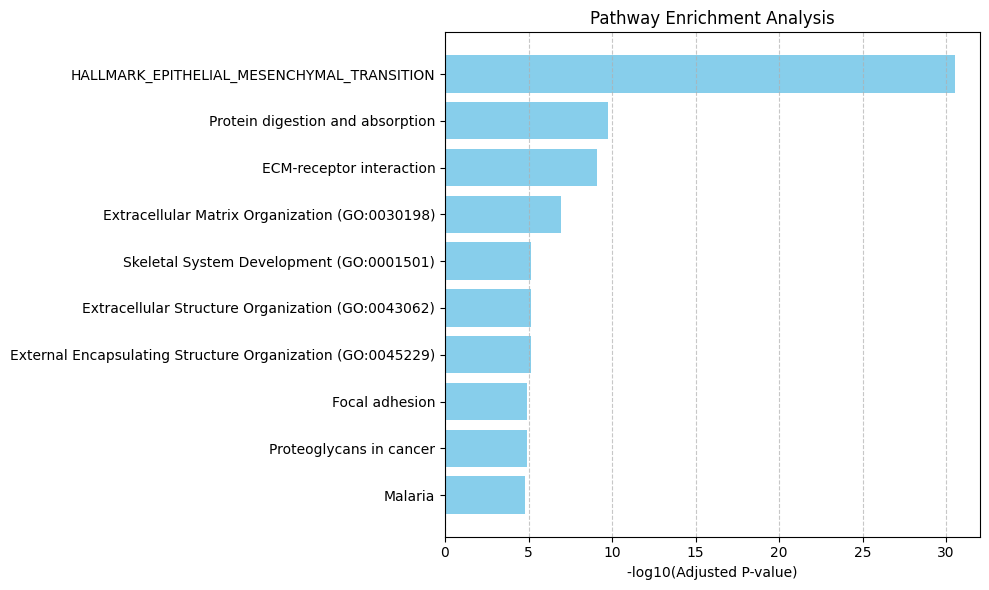

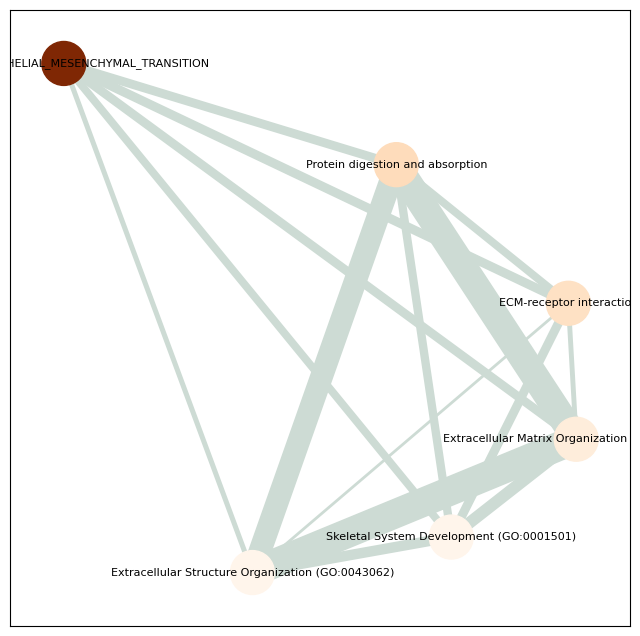

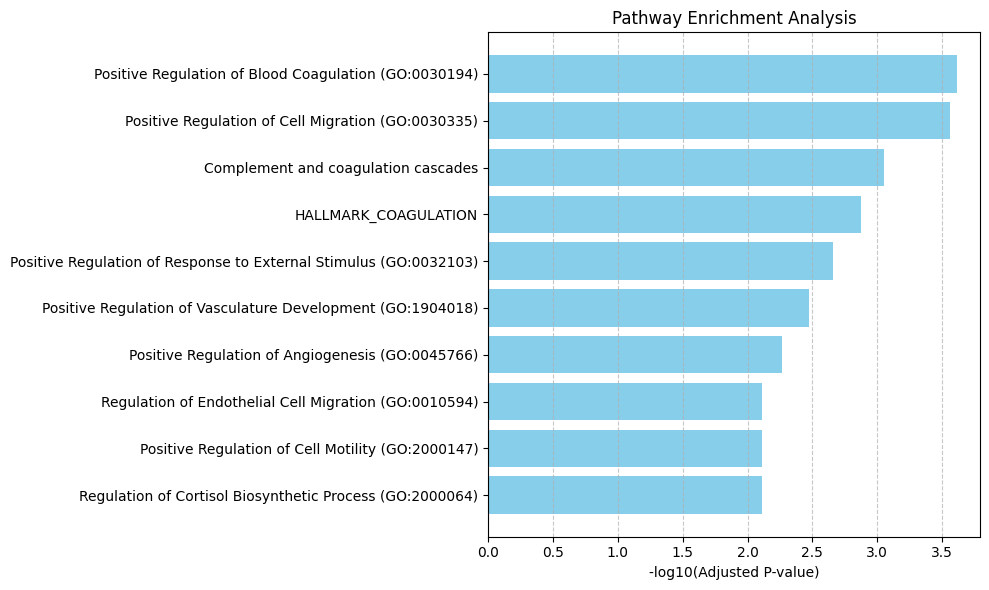

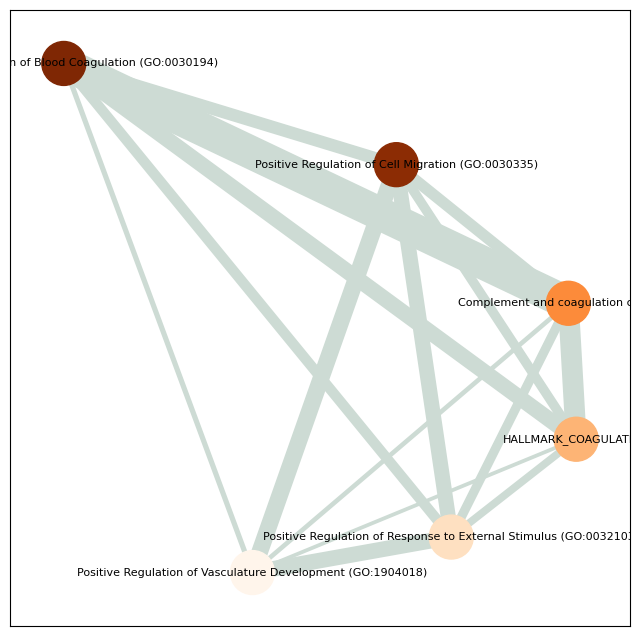

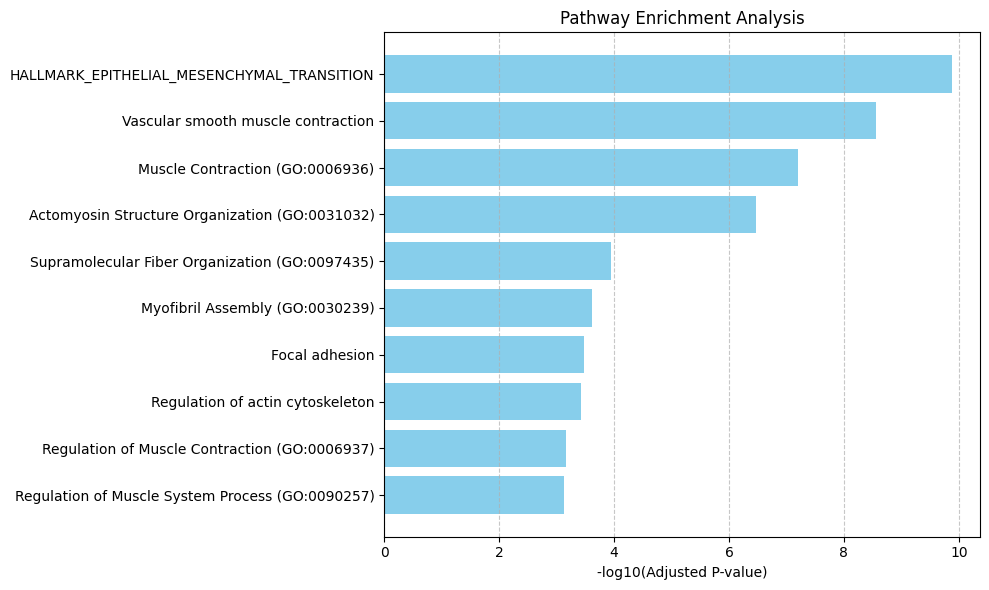

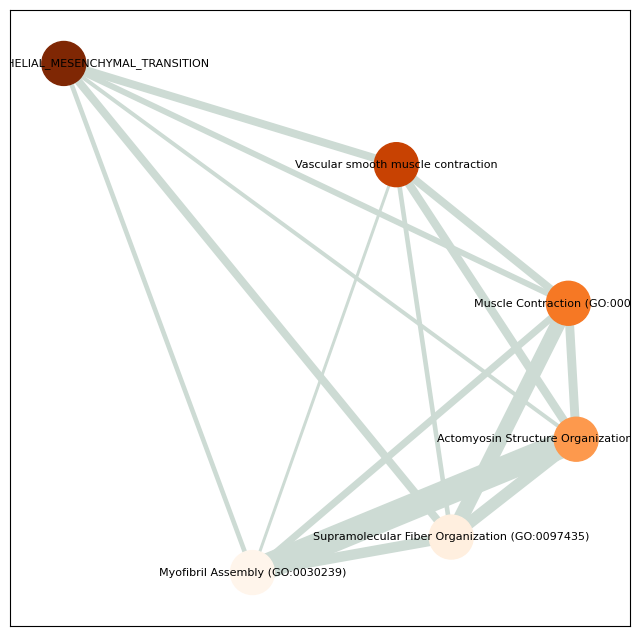

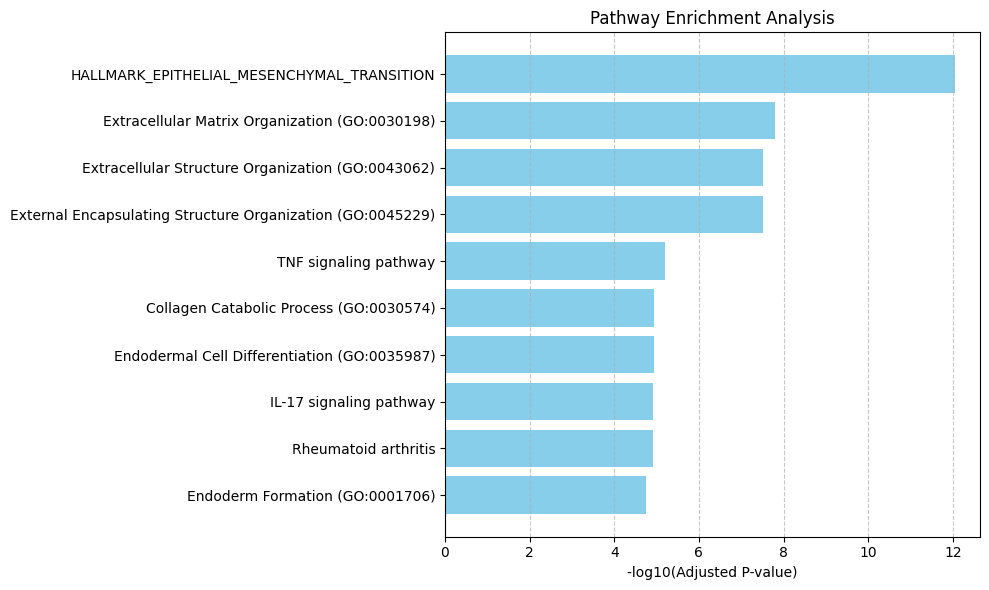

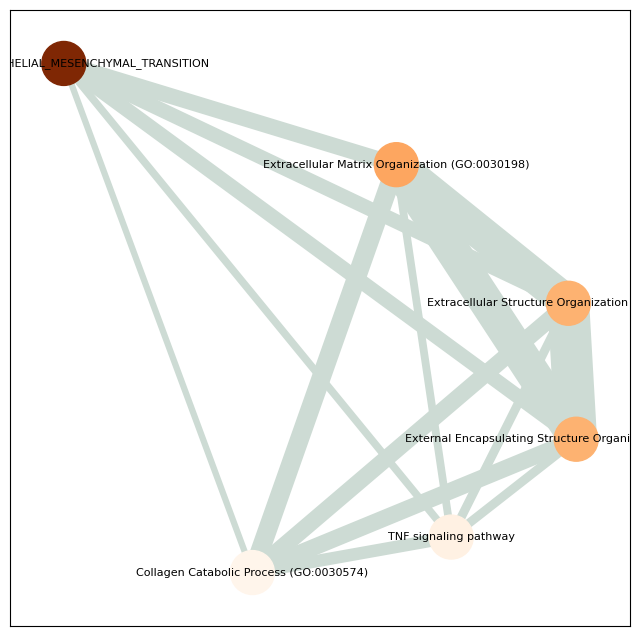

In [21]:
caf_cluster_num = '1' # Arch，
caf_cluster_num = '4' # Inflamed
caf_cluster_num = '5' # SMC-like
caf_cluster_num = '8' # Destructive

# for enrichment analysis
os.makedirs(f'{output_dir}/pathway', exist_ok = True)
from revise.analysis.bio import pathway_barplot, pathway_network_plot
for caf_cluster_num in focal_cluster_nums:
    pathway = all_pathway[all_pathway['group'] == caf_cluster_num]

    pathway_barplot(pathway, pathway_num = 10,  
                    save_file_name = f'{output_dir}/pathway/{caf_cluster_num}_barplot.pdf')
    pathway_network_plot(pathway, 
                        top_term = 6, 
                        save_file_name = f'{output_dir}/pathway/{caf_cluster_num}_network.pdf')

In [22]:
top_pathway = all_pathway.groupby('group').head(10)

top_pathway.reset_index(drop=True, inplace=True)
for caf_cluster_num in top_pathway['group'].unique():
    pathway = top_pathway[top_pathway['group'] == caf_cluster_num]
    print(caf_cluster_num, pathway['Term'].values)


1 ['HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION'
 'Protein digestion and absorption' 'ECM-receptor interaction'
 'Extracellular Matrix Organization (GO:0030198)'
 'Skeletal System Development (GO:0001501)'
 'Extracellular Structure Organization (GO:0043062)'
 'External Encapsulating Structure Organization (GO:0045229)'
 'Focal adhesion' 'Proteoglycans in cancer' 'Malaria']
4 ['Positive Regulation of Blood Coagulation (GO:0030194)'
 'Positive Regulation of Cell Migration (GO:0030335)'
 'Complement and coagulation cascades' 'HALLMARK_COAGULATION'
 'Positive Regulation of Response to External Stimulus (GO:0032103)'
 'Positive Regulation of Vasculature Development (GO:1904018)'
 'Positive Regulation of Angiogenesis (GO:0045766)'
 'Regulation of Endothelial Cell Migration (GO:0010594)'
 'Positive Regulation of Cell Motility (GO:2000147)'
 'Regulation of Cortisol Biosynthetic Process (GO:2000064)']
8 ['HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION'
 'Extracellular Matrix Organization (GO:0030198

In [23]:
pathway_dict = {
    "1": ['Epithelial Mesenchymal Transition', 'Protein digestion and absorption', 'ECM-receptor interaction', 'Focal adhesion'],
    "4": ['Positive Regulation of Blood Coagulation (GO:0030194)','Complement and coagulation cascades', 'IL-2/STAT5 Signaling', 'Interferon Alpha Response'],
    "5": ['Vascular smooth muscle contraction', 'Muscle Contraction (GO:0006936)', 'Actomyosin Structure Organization (GO:0031032)', 'Regulation of actin cytoskeleton'],
    "8": ['External Encapsulating Structure Organization (GO:0045229)',
         'TNF-alpha Signaling via NF-kB', 'TNF signaling pathway', 'IL-17 signaling pathway'],
}


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['ps.useafm'] = False      

def pathway_barplot(all_pathway, pathway_dict=None, select_metric='Adjusted P-value', cmap='RdBu_r', save_file_name=None):
    df = all_pathway.copy()
    
    if select_metric == 'Adjusted P-value':
        df["plot_value"] = -np.log10(df[select_metric])
        xlabel = '-log10(Adjusted P-value)'
    else:
        df["plot_value"] = df[select_metric]
        xlabel = select_metric
    
    if pathway_dict is None:
        pathway_dict = {}
        unique_groups = df['group'].unique()
        for group in unique_groups:
            group_pathways = df[df['group'] == group]['Term'].tolist()
            pathway_dict[group] = group_pathways
    
    all_groups = list(pathway_dict.keys())
    all_pathways = []
    for pathways in pathway_dict.values():
        all_pathways.extend(pathways)
    all_pathways = list(set(all_pathways))
    
    data_matrix = {}
    for pathway in all_pathways:
        data_matrix[pathway] = {}
        for group in all_groups:
            mask = (df['Term'] == pathway) & (df['group'] == group)
            if mask.any():
                data_matrix[pathway][group] = df[mask]['plot_value'].iloc[0]
            else:
                data_matrix[pathway][group] = 0  # Use 0 if absent
    
    if isinstance(cmap, dict):
        colors_dict = cmap
        def get_color(group):
            return colors_dict.get(str(group), '#808080')  # Default gray
    else:
        colors = plt.cm.get_cmap(cmap, len(all_groups))
        def get_color(group):
            color_idx = all_groups.index(group)
            return colors(color_idx)
    
    n_subplots = len(pathway_dict)
    fig, axes = plt.subplots(1, n_subplots, figsize=(12, 8))
    if n_subplots == 1:
        axes = [axes]
    
    for idx, (group_name, pathways) in enumerate(pathway_dict.items()):
        ax = axes[idx]
        
        bar_data = []
        bar_labels = []
        pathway_positions = []
        
        current_pos = 0
        group_spacing = 0.8  
        
        pathways = list(reversed(pathways))
        
        reversed_groups = list(reversed(all_groups))
        
        for pathway_idx, pathway in enumerate(pathways):
            pathway_start_pos = current_pos
            
            for group_idx, group in enumerate(reversed_groups):
                value = data_matrix[pathway][group]
                bar_data.append({
                    'position': current_pos,
                    'value': value,
                    'group': group,
                    'pathway': pathway
                })
                bar_labels.append(group)
                current_pos += group_spacing
            
            pathway_center = pathway_start_pos + (len(all_groups) - 1) * group_spacing / 2
            pathway_positions.append((pathway_center, pathway))
            
            current_pos += 1
        
        for bar in bar_data:
            color = get_color(bar['group'])
            ax.barh(bar['position'], bar['value'], color=color, alpha=0.8, 
                   edgecolor='black', linewidth=0.5, height=0.6)
        
        ax.set_yticks([pos for pos, _ in pathway_positions])
        ax.set_yticklabels([pathway for _, pathway in pathway_positions], 
                          fontsize=10, rotation=90, ha='right')
        
        separator_positions = []
        current_sep_pos = len(all_groups) * group_spacing - group_spacing/2
        for i in range(len(pathways) - 1):
            separator_positions.append(current_sep_pos + 0.5)
            current_sep_pos += len(all_groups) * group_spacing + 1
        
        for sep_pos in separator_positions:
            ax.axhline(y=sep_pos, color='gray', linestyle='--', alpha=0.7, linewidth=1)
        
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_title(f'{group_name}', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        
        ax.set_xlim(left=0)
        
        ax.set_ylim(-0.5, current_pos - 0.5)
    
    if isinstance(cmap, dict):
        legend_elements = [plt.Rectangle((0,0), 1, 1, facecolor=colors_dict.get(str(group), '#808080'), alpha=0.8, 
                                       edgecolor='black', linewidth=0.5) 
                          for group in all_groups]
    else:
        legend_elements = [plt.Rectangle((0,0), 1, 1, facecolor=colors(i), alpha=0.8, 
                                       edgecolor='black', linewidth=0.5) 
                          for i in range(len(all_groups))]
    
    fig.legend(legend_elements, all_groups, 
               loc='upper center', bbox_to_anchor=(0.5, 0.05), 
               ncol=len(all_groups), frameon=True, fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  
    
    if save_file_name:
        plt.savefig(save_file_name, dpi=300, bbox_inches='tight')
        print(f"Figure saved as {save_file_name}")
    else:
        plt.show()

Figure saved as /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_preview/Fibroblast/all-clusters-preview-20260820T105526Z/analysis/pathway_barplot.pdf


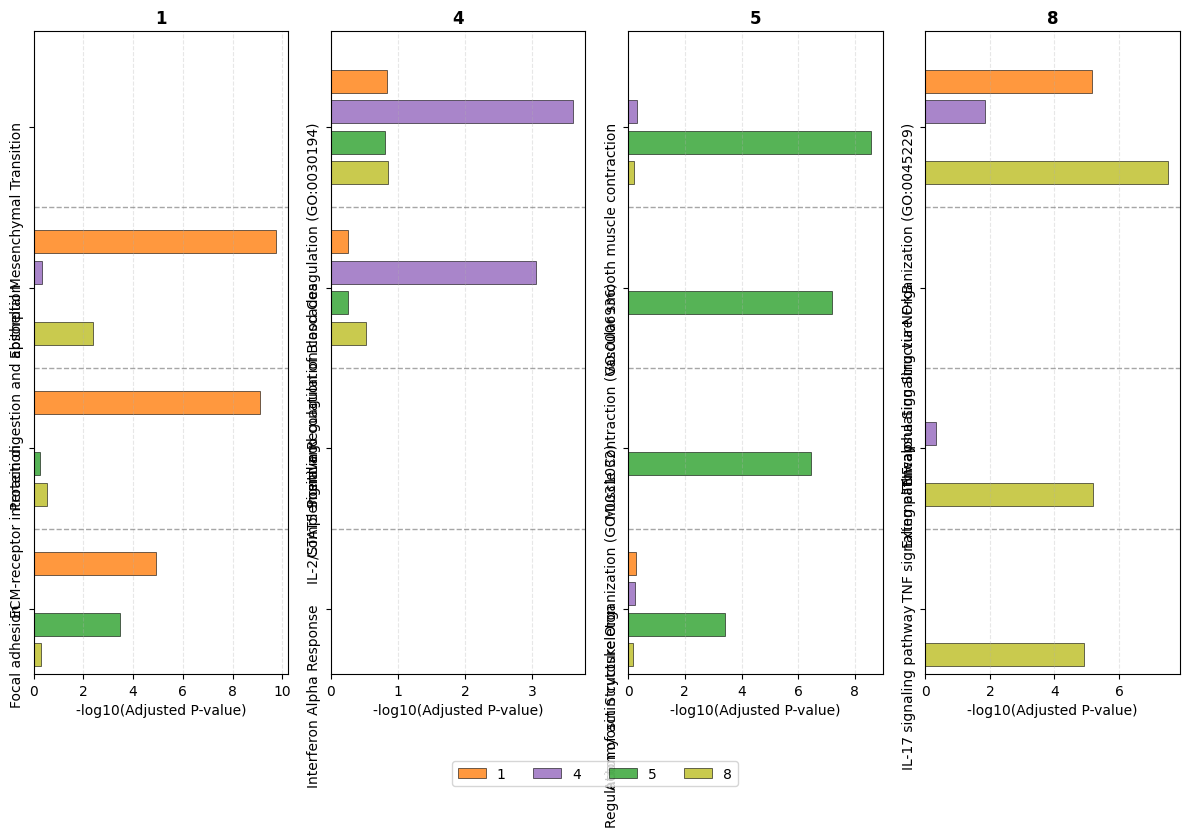

In [25]:
pathway_barplot(all_pathway[all_pathway['group'] != "6"], pathway_dict, 
                 cmap = {
                            "1": '#ff7f0e',
                            "5": '#2ca02c',
                            "4": '#9467bd',
                            "8": '#bcbd22',
                        },
                save_file_name=f'{output_dir}/pathway_barplot.pdf'
                )

## How do focal CAF states relate to Tumor and SMC compartments?

The following blocks are supporting spatial and expression views. They motivate the paper's niche hypotheses but are not quantitative co-localization, invasion, metabolic-coupling, or lineage tests.


### CAF_8 and Tumor: a supporting spatial association view

**Direct observation.** The plotted CAF_8 and Tumor cells occupy nearby regions in the current tissue map.

**Paper context.** The paper interprets CAF_8 as an ECM-breakdown state that may facilitate invasion. This notebook view alone does not establish that mechanism.


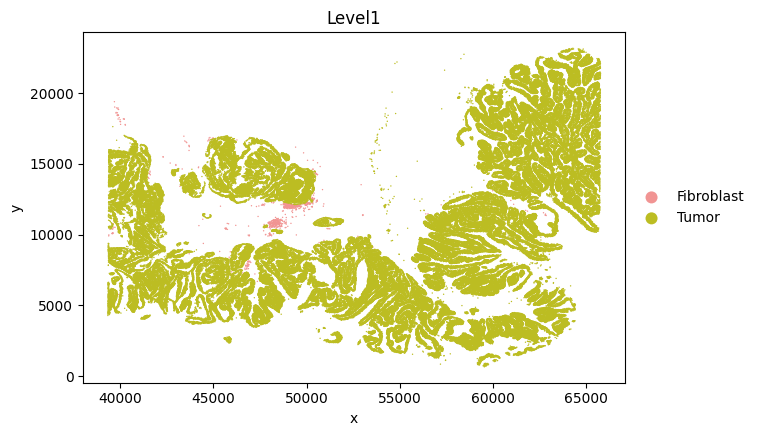

In [26]:
CAF_8_cells_names = sc_SVC_adata[sc_SVC_adata.obs['SVC_cluster'] == "8",:].obs['cell_id'].values
tumor_adata_sp = adata_sp[adata_sp.obs['Level1'] == "Tumor" ,:].copy()
CAF_8_adata_sp = adata_sp[adata_sp.obs['cell_id'].isin(CAF_8_cells_names),:].copy()
CAF_8_adata_sp.obs['Level1'] = "Fibroblast"
adata = tumor_adata_sp.concatenate(CAF_8_adata_sp)  
_apply_category_palette(adata, 'Level1', {'Tumor': '#bcbd22', 'Fibroblast': '#f19493'})

sc.pl.scatter(adata, x='x', y='y', color='Level1', size = 4)


### CAF_4, Tumor, LPL, and the Hypoxia-related pathway score

**Method and figure reading.** The first maps compare Tumor, background Fibroblast, and reconstructed CAF_4 locations; the violin plot compares LPL expression across reconstructed CAF groups. The score block reads the bundled `HYPOXIA_related_pathways.gmt`, uses the currently selected pathway gene set with `score_genes`, and displays the resulting Hypoxia-related pathway score in raw Xenium Tumor cells.

**Direct observation.** The current outputs show CAF_4/Tumor spatial distributions, LPL expression distributions, and the Tumor-cell Hypoxia-related pathway score. They do not constitute a quantitative test that CAF_4 preferentially localizes to a hypoxic front.

**Paper context.** The paper links CAF_4, hypoxic invasive-front regions, LPL, and potential metabolic coupling, with additional immunofluorescence evidence. Those mechanistic and validation claims are outside this notebook.


In [27]:
import scanpy as sc

sc_SVC_adata = sc.read(f"{case_dir}/spatial.h5ad")
CAF_adata_sc = sc.read(f"{case_dir}/expr.h5ad")


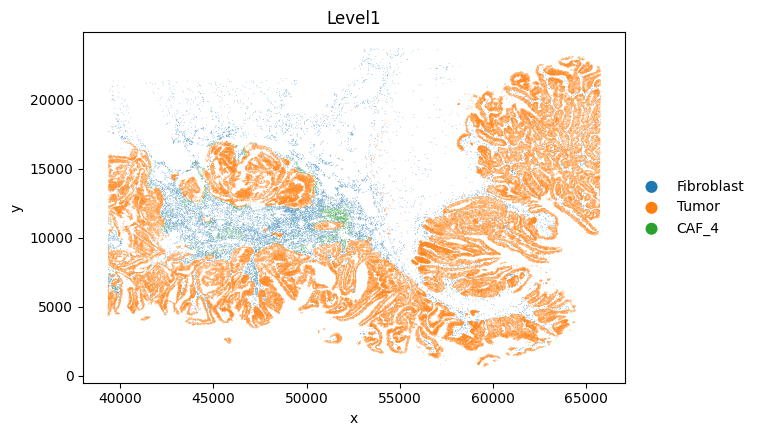

In [28]:
adata = adata_sp[adata_sp.obs['Level1'].isin(["Tumor", "Fibroblast"])].copy()
if hasattr(adata.obs['Level1'], 'cat') and "CAF_4" not in adata.obs['Level1'].cat.categories:
    adata.obs['Level1'] = adata.obs['Level1'].cat.add_categories(["CAF_4"])
caf_4_cell_ids = sc_SVC_adata.obs.loc[sc_SVC_adata.obs['SVC_cluster'] == "4", "cell_id"].values
adata.obs.loc[adata.obs['cell_id'].isin(caf_4_cell_ids), "Level1"] = "CAF_4"
sc.pl.scatter(adata, x="x", y="y", color="Level1")

In [29]:
adata.obs['Level1'].value_counts()

Level1
Tumor         145632
Fibroblast     15473
CAF_4           2136
Name: count, dtype: int64

In [30]:
import scanpy as sc
import pandas as pd

tumor_indices = adata.obs[adata.obs['Level1'] == 'Tumor'].index
fibroblast_indices = adata.obs[adata.obs['Level1'] == 'Fibroblast'].index
caf4_indices = adata.obs[adata.obs['Level1'] == 'CAF_4'].index

tumor_sampled = np.random.choice(tumor_indices, size=20000, replace=False)
fibroblast_sampled = np.random.choice(fibroblast_indices, size=3000, replace=False)
caf4_sampled = caf4_indices 

sampled_indices = np.concatenate([tumor_sampled, fibroblast_sampled, caf4_sampled])

new_adata = adata[sampled_indices, :].copy()
new_order = ['Tumor', 'Fibroblast', 'CAF_4']
current_categories = new_adata.obs['Level1'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in new_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
new_adata.obs['Level1'] = new_adata.obs['Level1'].cat.reorder_categories(ordered_categories)
_apply_category_palette(new_adata, 'Level1', {'Tumor': '#f09094', 'Fibroblast': '#d3d3d3', 'CAF_4': '#754e9e'})
new_adata.obs['Level1'].value_counts()


Level1
Tumor         20000
Fibroblast     3000
CAF_4          2136
Name: count, dtype: int64

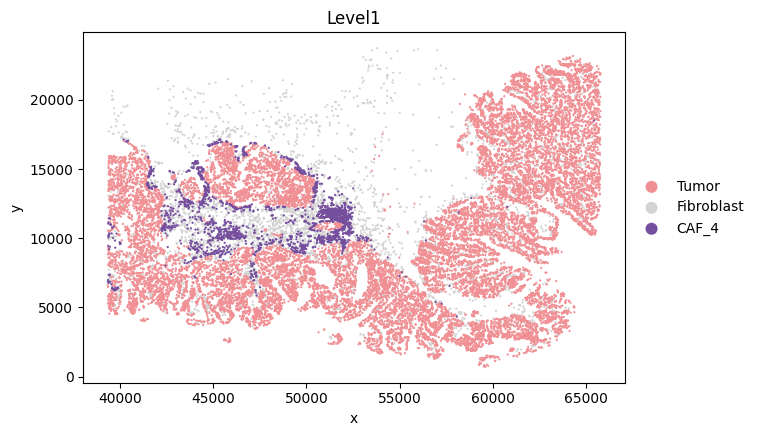

In [31]:
sc.pl.scatter(new_adata, x="x", y="y", color="Level1",size=10)

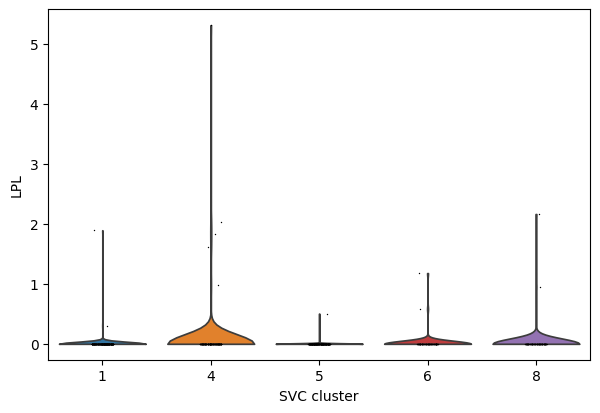

In [32]:
# compare gene LPL expression across subtypes
import scanpy as sc

sc_SVC_adata = sc.read(f"{case_dir}/spatial.h5ad")
CAF_adata_sc = sc.read(f"{case_dir}/expr.h5ad")


cluster_nums = analysis_cluster_nums
select_adata = CAF_adata_sc[CAF_adata_sc.obs['SVC_cluster'].isin(cluster_nums)]
sc.pp.normalize_per_cell(select_adata)


sc.pl.violin(select_adata, keys="LPL", groupby="SVC_cluster", show=False)
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42     
mpl.rcParams['ps.useafm'] = False     

plt.savefig(f"{output_dir}/sc_SVC_LPL_violin.pdf", dpi=300)
plt.show()


In [33]:
from revise.analysis.basic.gene_set_scoring import read_gmt, score_genes

HYPOXIA_pathway = read_gmt("./pathway/HYPOXIA_related_pathways.gmt")
HYPOXIA_pathway.keys()


dict_keys(['HIF-1 signaling pathway', 'Pyruvate metabolism', 'Glycolysis / Gluconeogenesis', 'Hypoxia', 'Glycolysis', 'Hypoxia_Glycolysis'])

In [34]:
import matplotlib.colors as mcolors
import numpy as np

colors = ["#d3d3d3", "#8b0000"]  
colors = ["white","#d3d3d3", "#8b0000"]  

n_bins = 100  

# colormap
cmap = mcolors.LinearSegmentedColormap.from_list("gray_to_darkred", colors, N=n_bins)

def plot_signature(adata, signatures, score_method="score_genes", score_name = "TLS", size = None, color_map = cmap, plot_type = "scatter", groupby='SVC_cluster', max_score = None):
    adata, score_name = score_genes(adata, signatures, score_name=score_name)

    if max_score is not None:
        adata.obs[score_name] = np.clip(adata.obs[score_name], None, max_score)
        
    if plot_type == "scatter":
        sc.pl.scatter(adata, x="x", y="y", 
                    color=score_name, 
                    color_map=color_map,
                    size = size,
                    )
    else:
        sc.pl.violin(adata, score_name, groupby=groupby)
    return adata

Glycolysis


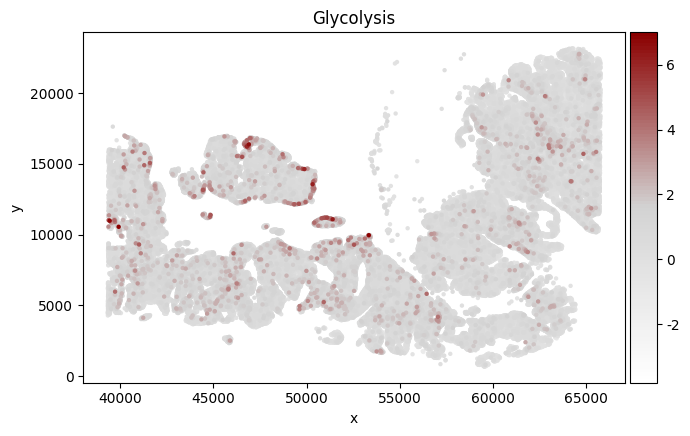

In [35]:
score_method = "score_genes"

size = 40
pathway_name = list(HYPOXIA_pathway.keys())[4]
print(pathway_name)
adata_sp_a = plot_signature(adata_sp[adata_sp.obs["Level1"] == "Tumor"], HYPOXIA_pathway[pathway_name], 
               score_method=score_method, score_name = pathway_name, 
               color_map = cmap,
               size = size,
               max_score=7)
adata_sp_a.obs[[pathway_name]].rename(columns={pathway_name: "score"}).rename_axis("obs_name").to_csv(f"{output_dir}/score_genes.csv")


### CAF_5 and SMC: marker and spatial comparisons

**Method and figure reading.** MYH11 expression is compared across SMC and reconstructed CAF groups, followed by a spatial display of SMC and CAF_5 cells.

**Direct observation.** CAF_5 retains an SMC-associated marker and is displayed near SMC regions in this case. These outputs motivate, but do not establish, a lineage relationship.

**Paper context.** The paper describes CAF_5 as SMC-like and reports metastatic-cohort, immunofluorescence, and lineage-tracing evidence. Those external validations are not reproduced here.


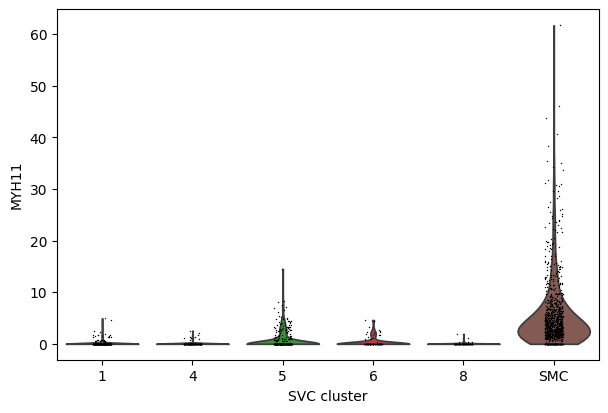

In [36]:
import scanpy as sc

SMC_adata = adata_sc[adata_sc.obs['Level1']== "SMC",:]
SMC_adata.obs['SVC_cluster'] = "SMC"
CAF_adata_sc = sc.read(f"{case_dir}/expr.h5ad")


cluster_nums = analysis_cluster_nums
select_adata = CAF_adata_sc[CAF_adata_sc.obs['SVC_cluster'].isin(cluster_nums)]
select_adata = SMC_adata.concatenate(select_adata)
sc.pp.normalize_per_cell(select_adata)
# sc.pp.log1p(select_adata)
sc.pl.violin(select_adata, keys="MYH11", groupby="SVC_cluster")


In [37]:
import pandas as pd
desired_order = ['SMC', '1', '4', '5', '6', '8']
select_adata.obs['SVC_cluster'] = pd.Categorical(select_adata.obs['SVC_cluster'], categories=desired_order, ordered=True)

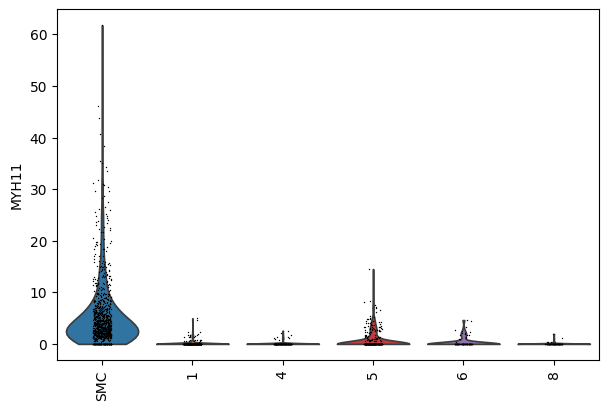

In [38]:
sc.pl.violin(select_adata, keys="MYH11", groupby="SVC_cluster", rotation=90, show=False)

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42     
mpl.rcParams['ps.useafm'] = False     

plt.savefig(f"{output_dir}/sc_SVC_MYH11_violin.pdf", dpi=300)
plt.show()


In [39]:
CAF_5_cells_names = sc_SVC_adata[sc_SVC_adata.obs['SVC_cluster'] == "5",:].obs['cell_id'].values
SMC_adata_sp = adata_sp[adata_sp.obs['Level1'] == "SMC" ,:].copy()
SMC_adata_sp.obs['SVC_cluster'] = "SMC"
CAF_5_adata_sp = adata_sp[adata_sp.obs['cell_id'].isin(CAF_5_cells_names),:].copy()
CAF_5_adata_sp.obs['Level1'] = "Fibroblast"
CAF_5_adata_sp.obs['SVC_cluster'] = "5"
adata = SMC_adata_sp.concatenate(CAF_5_adata_sp)  


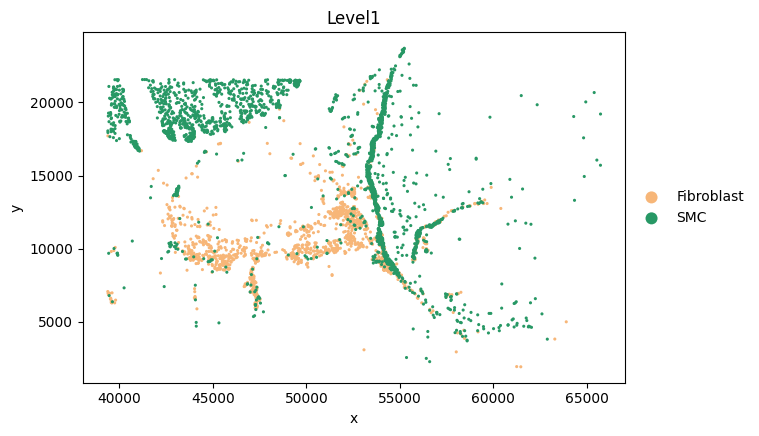

In [40]:

_apply_category_palette(adata, 'Level1', {'SMC': '#279865', 'Fibroblast': '#f7b678'})

sc.pl.scatter(adata, x='x', y='y', color='Level1', size = 20)


## SMC–CAF_5 Palantir trajectory ordering

**Question.** Do the selected SMC and CAF_5 cells form a continuous ordering in the chosen representation?

**Method.** OmicVerse performs the recorded preprocessing, scaling, and PCA steps; `revise.analysis.advanced.trajectory.infer_palantir` then runs Palantir with SMC as the origin and Fibroblast as the terminal group. The saved pseudotime and UMAP panels display the inferred ordering, cluster identity, and available MYH11, ACTA2, FAP, and COL1A1 markers.

**Direct observation.** The existing result provides a Palantir ordering and marker display for the selected cells. The marker panels are descriptive; they are not a marker-versus-pseudotime trend test, and the ordering does not establish lineage.

**Paper context.** The paper reports a proposed SMC-to-CAF_5 transition supported by additional marker trends, cohorts, immunofluorescence, and in-vivo lineage tracing. Those validations remain outside this notebook.


In [41]:
import scanpy as sc
import matplotlib.pyplot as plt
try:
    import omicverse as ov
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Install trajectory dependencies with pip install \"revise-svc[trajectory]\"') from exc
from revise.analysis.advanced.trajectory import infer_palantir
ov.plot_set()

adata=ov.pp.preprocess(adata, mode='shiftlog|pearson',n_HVGs=3000)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
🚫 No CUDA devices found

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.5   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

Begin robust gene identification
After filtration, 343/343 genes are kept.     Among 343 genes, 343 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell


The following highly-expressed genes are not considered during normalization factor computation:
['ACTA2', 'DES', 'GREM1', 'IGFBP7', 'IGHG3', 'MMP2', 'TAGLN', 'TGFBI', 'THBS1']


    finished (0:00:00)


extracting highly variable genes


--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)


Time to analyze data in cpu: 0.45873594284057617 seconds.
End of size normalization: shiftlog and HVGs selection pearson
computing PCA


    with n_comps=50


    finished (0:00:00)


In [42]:
pseudotime = infer_palantir(
    adata,
    groupby='Level1',
    basis='X_umap',
    use_rep='scaled|original|X_pca',
    n_comps=50,
    origin_cells='SMC',
    terminal_cells=["Fibroblast"],
    num_waypoints=500,
)
pseudotime.rename("pseudotime").rename_axis("obs_name").to_csv(f"{output_dir}/palantir_pseudotime.csv")
Path(f"{output_dir}/palantir-evidence.json").write_text(
    json.dumps({
        "groupby": "Level1",
        "basis": "X_umap",
        "use_rep": "scaled|original|X_pca",
        "n_comps": 50,
        "origin_cells": "SMC",
        "terminal_cells": ["Fibroblast"],
        "num_waypoints": 500,
    }, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for y

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as ear

ranking genes


...

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for y

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/omicverse/utils/_data.py:324: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as ear

Time for shortest paths: 0.27879860003789264 minutes
Iteratively refining the pseudotime...


Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


195

In [43]:
adata.obs['SVC_cluster'] = adata.obs['SVC_cluster'].astype(str).astype('category')
if 'SMC' not in adata.obs['SVC_cluster'].cat.categories:
    adata.obs['SVC_cluster'] = adata.obs['SVC_cluster'].cat.add_categories('SMC')
adata.obs['SVC_cluster'] = adata.obs['SVC_cluster'].fillna('SMC')


In [44]:
adata.obs['SVC_cluster'] = adata.obs['SVC_cluster'].replace('nan', 'SMC')

computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)


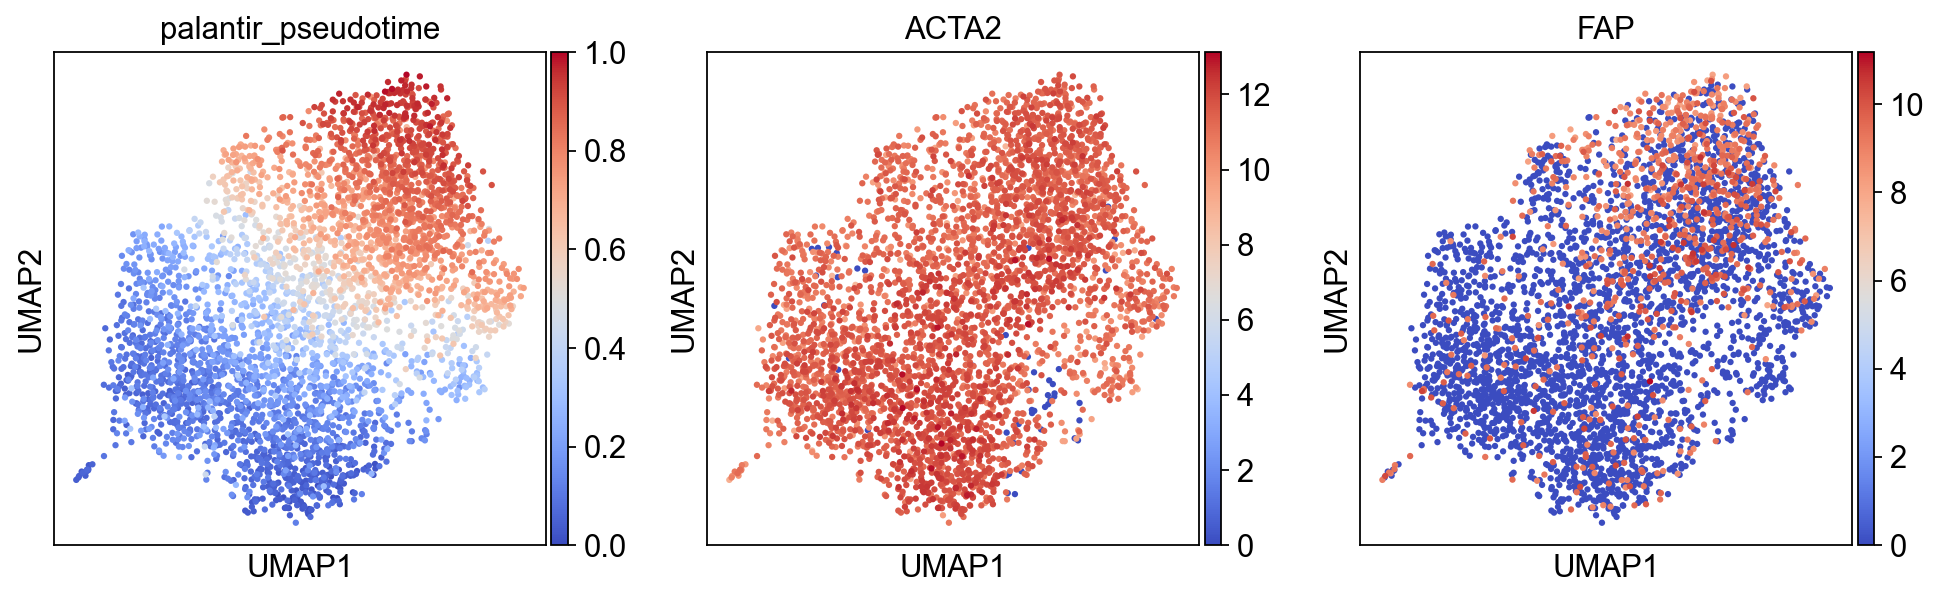

In [45]:
if 'X_umap' not in adata.obsm:
    if 'neighbors' not in adata.uns:
        sc.pp.neighbors(adata, use_rep='X_pca' if 'X_pca' in adata.obsm else None)
    sc.tl.umap(adata, random_state=0)

umap_features = ['palantir_pseudotime', 'MYH11', 'ACTA2', 'FAP', 'COL1A1']
umap_features = [feature for feature in umap_features if feature in adata.obs or feature in adata.var_names]
sc.pl.umap(adata, color=umap_features, cmap = "coolwarm")


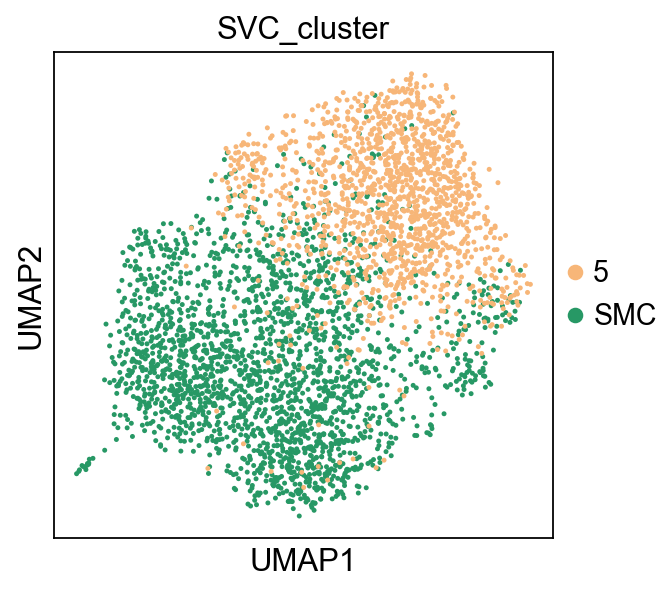

In [46]:
_apply_category_palette(adata, 'SVC_cluster', {'SMC': '#279865', '5': '#f7b678'})
sc.pl.umap(adata, color=['SVC_cluster'], size=20)
